# 1- Linear Regression:

In [2]:
#     بنائا على العمر والجنس والسكن......نريد معرفه متوسط التكاليف الطبيه في العام الواحد
#     ما هو المبلغ الذي يجب تحصيله من العميل مقابل التامين

In [3]:
#medical_charges_url ='https://raw.githubusercontent.com/JovianML/opendata'
#from urllib.request import urlretrive
#urlretrieve(medical_charges_url, 'medical.csv')
    

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import numpy as np

In [5]:
medical_df = pd.read_csv('insurance.csv')

In [6]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
medical_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

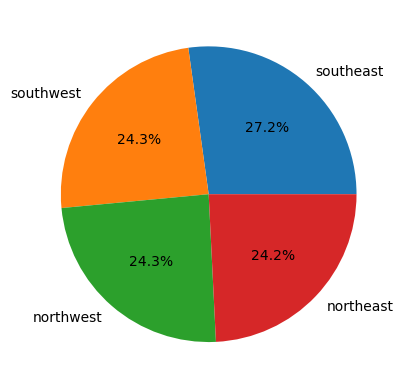

In [9]:
plt.pie(medical_df['region'].value_counts().values, labels = medical_df['region'].value_counts().index,autopct='%1.1f%%');

In [10]:
medical_df.describe()
#   نلاحظ في العامود الكبير ان اقل من 75 هي قيم قليله واكثر منها اصبح يوجد انحراف في البيانات وهذا يدل على وجود قيم متطرفه8

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
#    لحفظ المشروع
# import jovian
# jovian.commit(filename='Scikit Learning.ipynb')

#  Exploratory Analysis and Visualization

In [13]:

sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['figure.facecolor'] = '#00000000'

In [14]:
# age
medical_df['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

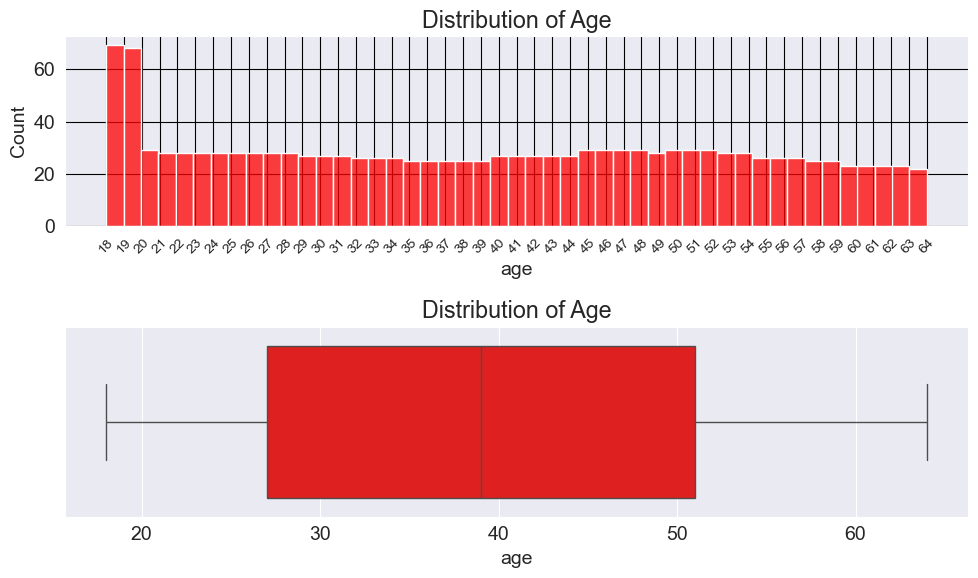

In [15]:
# bins = 64 - 18 +1
plt.subplot(2,1,1)
sns.histplot(data = medical_df, x = 'age', color = 'r', bins = 47)
plt.title('Distribution of Age')
plt.grid(color='black')
plt.xticks(range(18,65,1), rotation =45, fontsize = 10)
plt.subplot(2,1,2)
sns.boxplot(data = medical_df, x = 'age', color = 'r')
plt.title('Distribution of Age')
plt.tight_layout()
plt.show()
#    نلاحظ ان الاعمار مزعه بالتساوي من 20 ل 30 عميل في كل عمر عدا الاعمار 18 و 19 لذالك لا يوجد تباين في البيانات 

In [16]:
#bmi
medical_df.bmi.describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

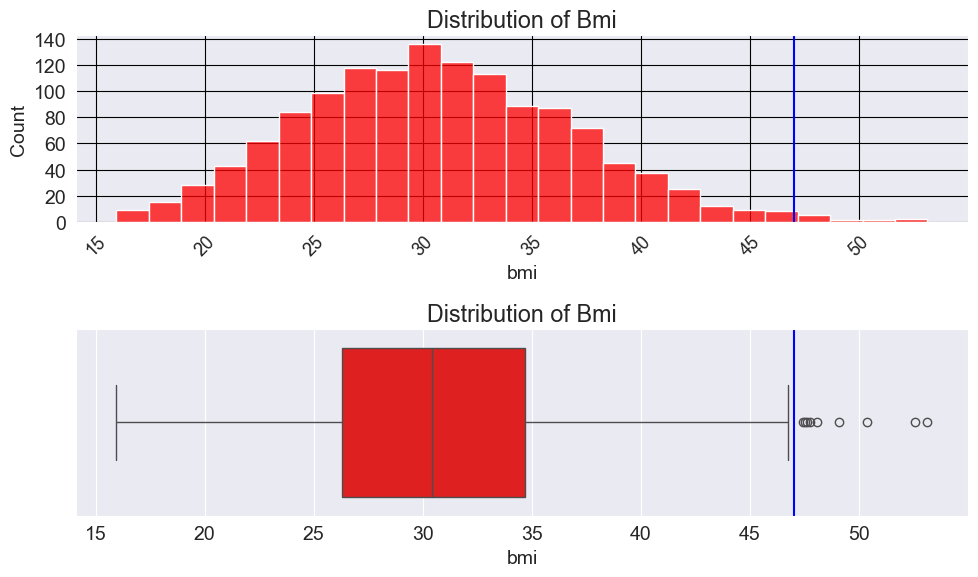

In [17]:
plt.subplot(2,1,1)
sns.histplot(data = medical_df, x = 'bmi', color = 'r')
plt.title('Distribution of Bmi')
plt.grid(color='black')
plt.xticks( rotation =45, fontsize = 13)
plt.yticks(range(0,151,20))
plt.axvline(47, color = 'blue')
plt.subplot(2,1,2)
sns.boxplot(data = medical_df, x = 'bmi', color = 'r')
plt.title('Distribution of Bmi')
plt.axvline(47, color = 'blue')
plt.tight_layout()
plt.show()
#     توزيع طبيعي(غاوسي)

In [18]:
# charges
medical_df['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

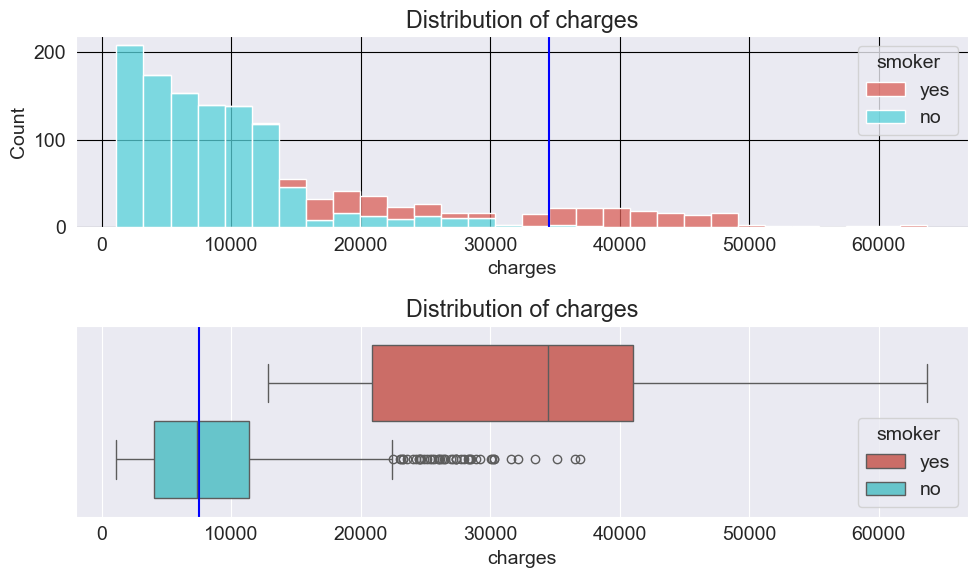

In [19]:
plt.subplot(2,1,1)
sns.histplot(data = medical_df, x = 'charges', hue = 'smoker', color = 'r', palette = 'hls', multiple='stack')
plt.title('Distribution of charges')
plt.grid(color='black')
plt.axvline(34500, color = 'blue')
plt.subplot(2,1,2)
sns.boxplot(data = medical_df, x = 'charges', hue = 'smoker', color = 'r', palette = 'hls')
plt.title('Distribution of charges')
plt.axvline(7500, color = 'blue')
plt.tight_layout()
plt.show()
#     توزيع اسي او توزيع القوه نلاحظ طرف يحتوي على عدد اكبر من طرف اخر
#     في هذه الحاله يجب عدم استخدام المودل لانه يريد توزيع طبيعي

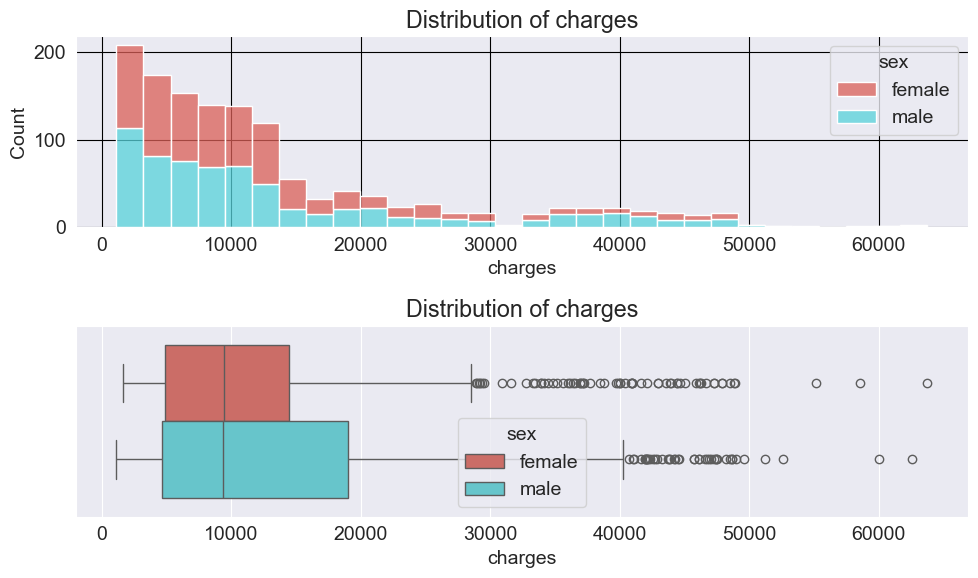

In [20]:
plt.subplot(2,1,1)
sns.histplot(data = medical_df, x = 'charges', hue = 'sex', color = 'r', palette = 'hls', multiple='stack')
plt.title('Distribution of charges')
plt.grid(color='black')
plt.subplot(2,1,2)
sns.boxplot(data = medical_df, x = 'charges', hue = 'sex', color = 'r', palette = 'hls')
plt.title('Distribution of charges')
plt.tight_layout()
plt.show()
#  نلاحظ وجود قيم شاذه ولكن الجنس وحده ليس عامل موثر على التكلفه لانه متساوي بين الذكور والاناث

In [21]:
from scipy.stats import f_oneway
m = medical_df[medical_df['sex'] == 'male']['charges']
f = medical_df[medical_df['sex'] == 'female']['charges']
# ANOVA
f_stat, p_value = f_oneway(m, f)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.5f}")

F-statistic: 4.40
P-value: 0.03613


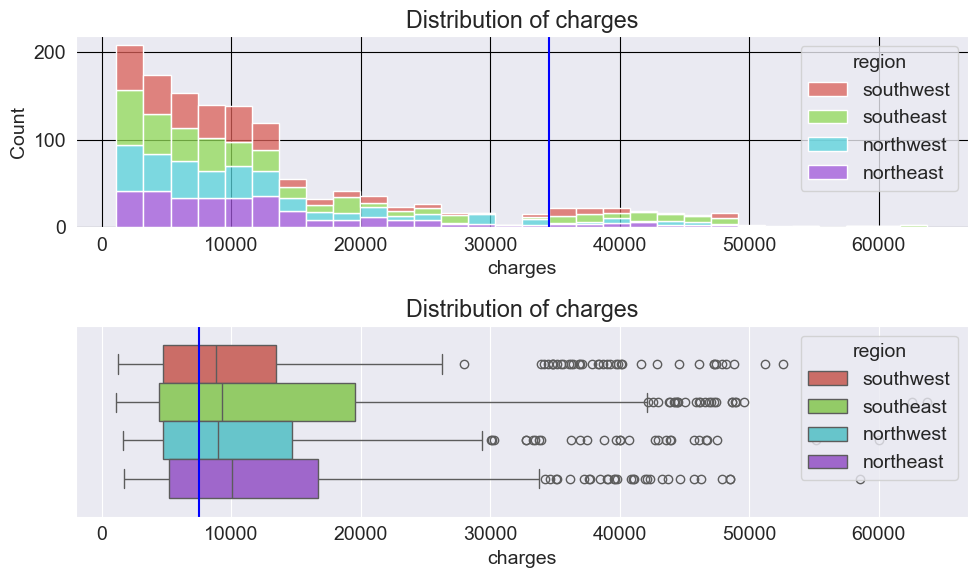

In [22]:
plt.subplot(2,1,1)
sns.histplot(data = medical_df, x = 'charges', hue = 'region', color = 'r', palette = 'hls', multiple='stack')
plt.title('Distribution of charges')
plt.grid(color='black')
plt.axvline(34500, color = 'blue')
plt.subplot(2,1,2)
sns.boxplot(data = medical_df, x = 'charges', hue = 'region', color = 'r', palette = 'hls')
plt.title('Distribution of charges')
plt.axvline(7500, color = 'blue')
plt.tight_layout()
plt.show()
#   منطقة Southeast لديها أعلى انتشار للتكاليف
# يظهر في الـ Boxplot أن منطقة southeast لديها نطاق واسع وذيل طويل.
# ما قد يشير إلى وجود عدد أكبر من الحالات ذات التكاليف العالية هناك.
# لا فرق جذري بين المناطق الأخرى southwest, northwest, northeast كلها قريبة من بعضها في التوزيع. الفرق بينها ليس كبيرًا.


In [23]:
from scipy.stats import f_oneway
sw = medical_df[medical_df['region'] == 'southwest']['charges']
se = medical_df[medical_df['region'] == 'southeast']['charges']
nw = medical_df[medical_df['region'] == 'northwest']['charges']
ne = medical_df[medical_df['region'] == 'northeast']['charges']

# ANOVA
f_stat, p_value = f_oneway(sw, se, nw, ne)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.5f}")
#✅ التفسير:
#- إذا كان p-value < 0.05 → نرفض الفرضية H₀ → المنطقة تؤثر على التكاليف.
#- إذا كان p-value ≥ 0.05 → نقبل H₀ → لا يوجد فرق معنوي بين المناطق.


F-statistic: 2.97
P-value: 0.03089


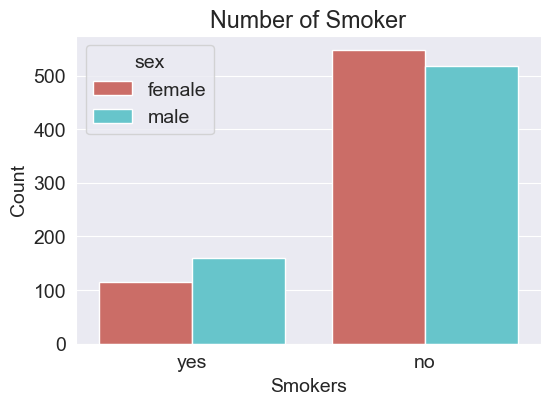

In [24]:
plt.figure(figsize = (6,4))
sns.countplot(data = medical_df,  x = 'smoker', hue = 'sex', palette = 'hls')
plt.xlabel('Smokers')
plt.ylabel('Count')
plt.title('Number of Smoker')
plt.show()

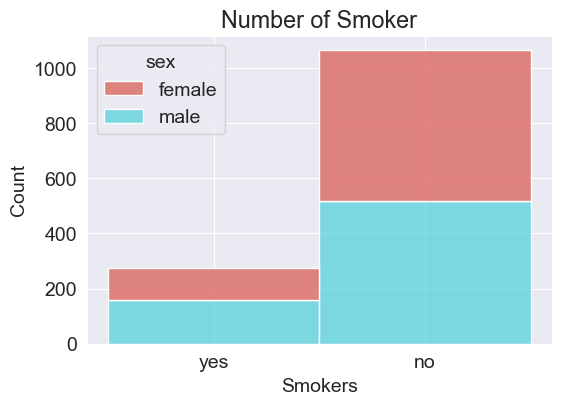

In [25]:
plt.figure(figsize = (6,4))
sns.histplot(data = medical_df,  x = 'smoker', hue = 'sex', palette = 'hls', multiple='stack')
plt.xlabel('Smokers')
plt.ylabel('Count')
plt.title('Number of Smoker')
plt.show()
# وجد لدينا ان 20 هم مدخنين لكن المودل سوف يطبق على مجتمع لذالك يجب التاكد هل فعلا فقط 20 من المجتمع هم مدخنيين؟

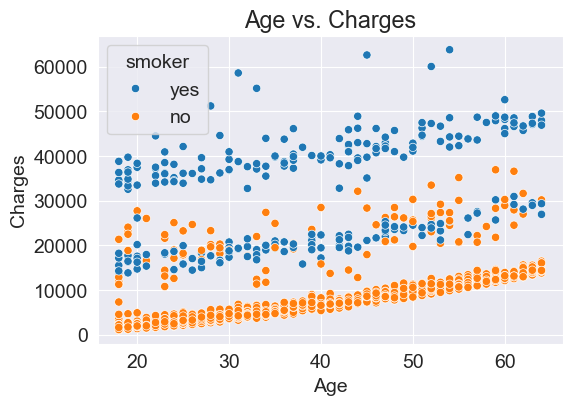

In [26]:
#Age and Charges
plt.figure(figsize = (6,4))
sns.scatterplot(data = medical_df, x = 'age', y = 'charges', hue = 'smoker') 
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs. Charges')
plt.show()
# نلاحظ وجود ثلاث مجموعات كل مجموعه لديها خط متزايد مع ميل متزايد

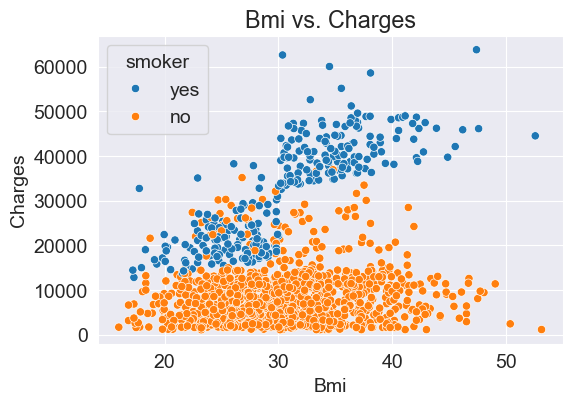

In [27]:
#Bmi and Charges
plt.figure(figsize = (6,4))
sns.scatterplot(data = medical_df, x = 'bmi', y = 'charges', hue = 'smoker') 
plt.xlabel('Bmi')
plt.ylabel('Charges')
plt.title('Bmi vs. Charges')
plt.show()

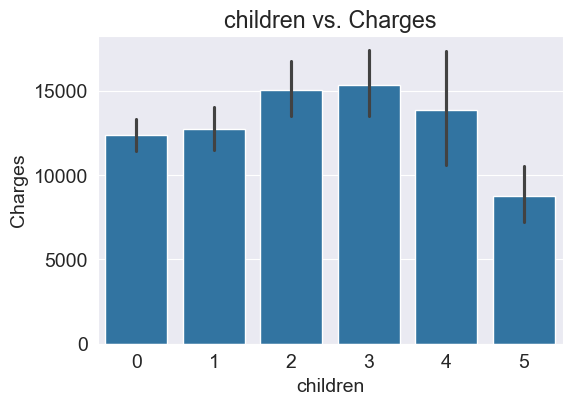

In [28]:
plt.figure(figsize = (6,4))
sns.barplot(data = medical_df, x = 'children', y = 'charges') 
plt.xlabel('children')
plt.ylabel('Charges')
plt.title('children vs. Charges')
plt.show()

<Axes: xlabel='children', ylabel='charges'>

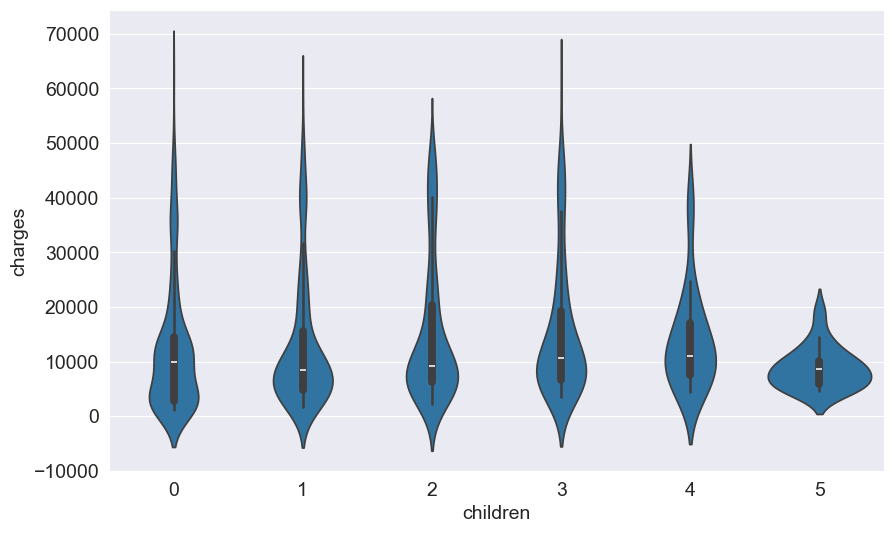

In [29]:
sns.violinplot(data = medical_df, x = 'children', y = 'charges')

# Correlation
- الارتباط: هو وجود علاقة أو ترابط بين متغيرين؛ عندما يتغير أحدهما يميل الآخر إلى التغير أيضاً. مثلًا: إذا زادت مبيعات المثلجات، قد يزيد استخدام المكيفات. هذا يدل على ارتباط بين المتغيرين لكنه لا يعني أن أحدهما يسبب الآخر.
-  العلاقات السببية (السببية): تعني أن تغيير متعمد في متغير واحد يؤدي بشكل مباشر إلى تغيير في المتغير الآخر.


 لماذا لا يمكن تفسير العلاقات السببية من الارتباط؟

1. العلاقة العكسية (Reversibility issue): قد يكون المتغير B هو السبب لـ A وليس العكس، أو العكس صحيح.

2. المتغير الثالث الخفي (Confounding): قد يكون هناك متغير ثالث يؤثر على كلا المتغيرين A و B، مما يجعلهما يرتبطان لكن ليس بسبب تأثير مباشر بينهما.

3. الارتباط العشوائي (Coincidental correlation): أحيانًا قد يحدث ارتباط فقط بالصدفة أو بسبب بيانات محدودة.

يعرف اذا كان عمودان مرتبطان مع بعض
 العلاقة الإحصائية بين متغيرين (هل يتحركان معًا أم لا)، وليس العلاقة السببية.

السبب في ذلك:

الارتباط لا يُظهر الاتجاه السببي:
  لانعرف هل تسبب احد في الاخر او ان يكون هناك عامل اخر يؤثر عليهم y مع xاذا ارتفع  
لا نعرف


In [31]:
medical_df_corr = medical_df.select_dtypes(include= ['number']).corr()
medical_df_corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

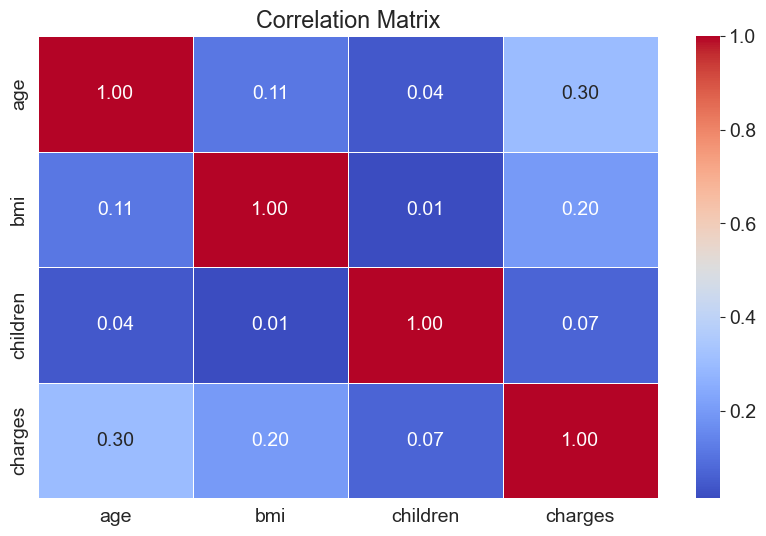

In [32]:
sns.heatmap(data = medical_df_corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt = '.2f')
plt.title('Correlation Matrix')

In [33]:
smoker_value = {'yes' : 1, 'no' : 0}
smoker_numeric = medical_df.smoker.map(smoker_value)
# map:  تاخذ تابع او قاموس وتطبقه على كل قيمه
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [34]:
medical_df.charges.corr(smoker_numeric)

0.7872514304984772

In [35]:
sex_value = {'male' : 1, 'female' : 0}
sex_numeric = medical_df.sex.map(sex_value)
# map:  تاخذ تابع او قاموس وتطبقه على كل قيمه
medical_df.charges.corr(sex_numeric)

0.057292062202025415

In [36]:
#    الترقيم يؤثر لأن خوارزمية الارتباط تفترض أن الأرقام لها معنى ترتيبي أو عددي.
region_value = {'southeast' : 0, 'southwest' : 1, 'northwest' : 2, 'northeast' : 3}
region_numeric = medical_df.region.map(region_value)
# map:  تاخذ تابع او قاموس وتطبقه على كل قيمه
medical_df.charges.corr(region_numeric)

-0.039473383476402175

In [37]:
medical_df.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

# Linear Regression using a Single Feature

<Axes: xlabel='age', ylabel='charges'>

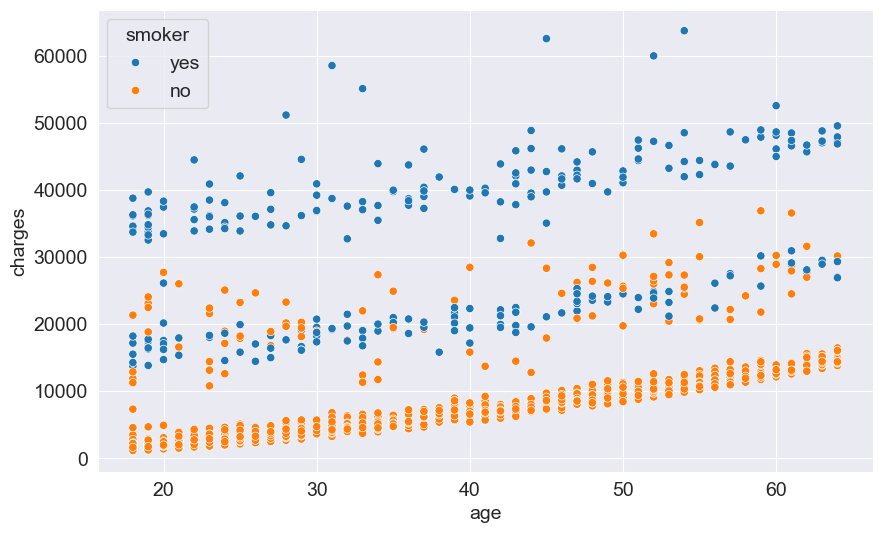

In [39]:
sns.scatterplot(data = medical_df, x = 'age', y = 'charges', hue = 'smoker')

In [40]:
no_smoker_df = medical_df[medical_df['smoker'] == 'no']

Text(0.5, 1.0, 'Age vs. Charges')

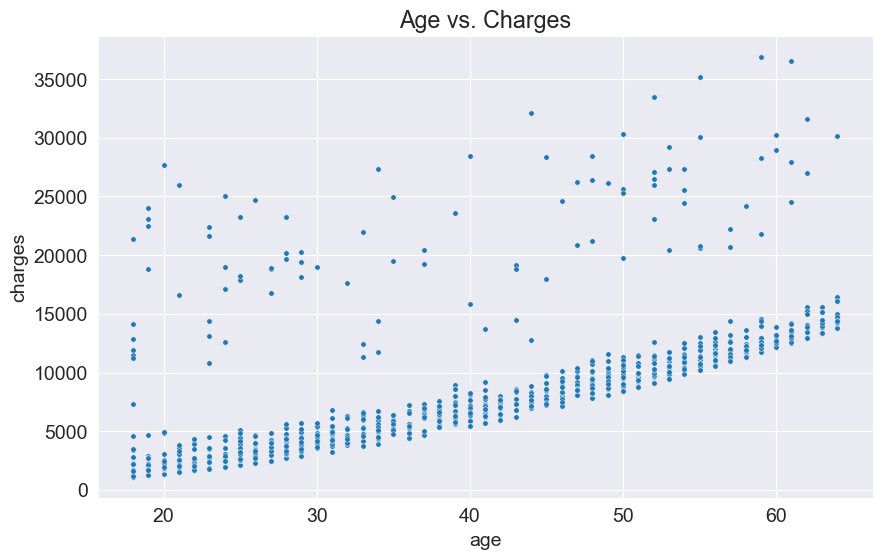

In [41]:
sns.scatterplot(data = no_smoker_df, x = 'age', y = 'charges', s = 15)
plt.title('Age vs. Charges')

In [42]:
def estimate_charges(age, w, b):
    return w *age +b

In [43]:
w = 50
b = 100
estimate_charges(22, w, b)

1200

In [44]:
ages = no_smoker_df.age

In [45]:
estimated_charges = estimate_charges(ages, w, b)

Text(0, 0.5, 'Estimated Charges')

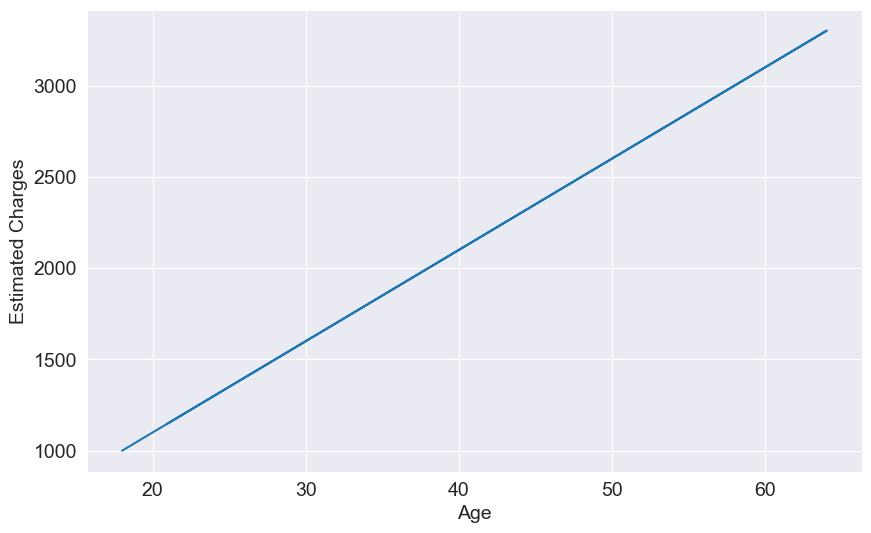

In [46]:
plt.plot(ages, estimated_charges)
plt.xlabel('Age')
plt.ylabel('Estimated Charges')

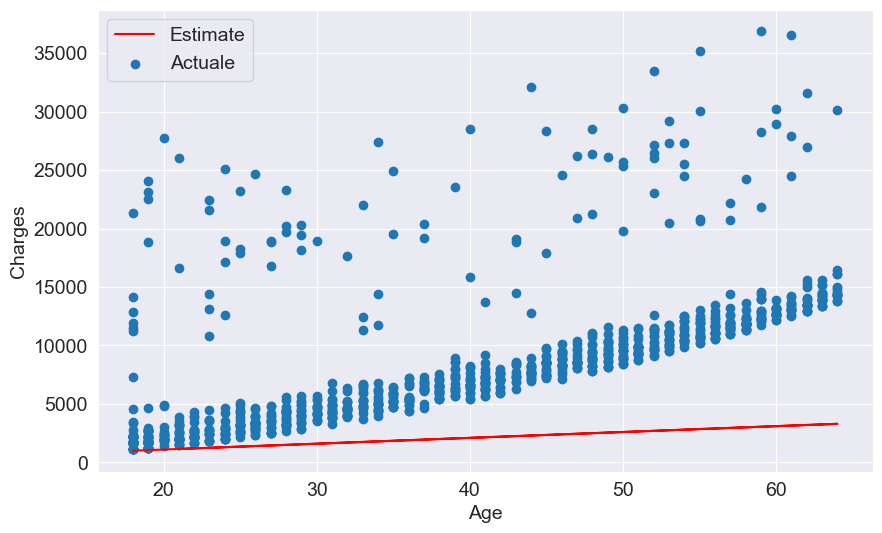

In [47]:
plt.plot(ages, estimated_charges, color = 'red')
plt.scatter(ages, no_smoker_df.charges)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actuale'])

In [48]:
def try_parameters(w, b):
    ages = no_smoker_df.age
    target = no_smoker_df.charges
    estimated_charges = estimate_charges(ages, w, b)
    plt.plot(ages, estimated_charges, color = 'red')
    plt.scatter(ages, target)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actuale'])

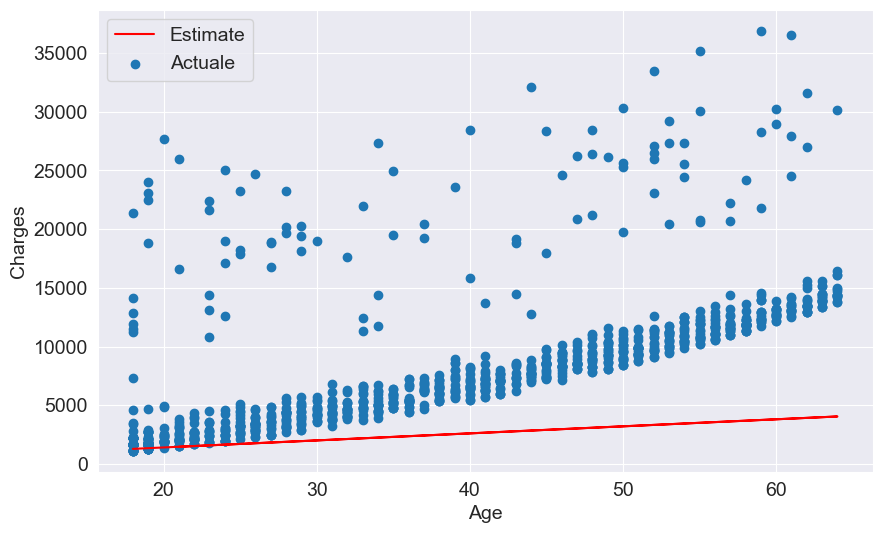

In [49]:
try_parameters(60, 200)

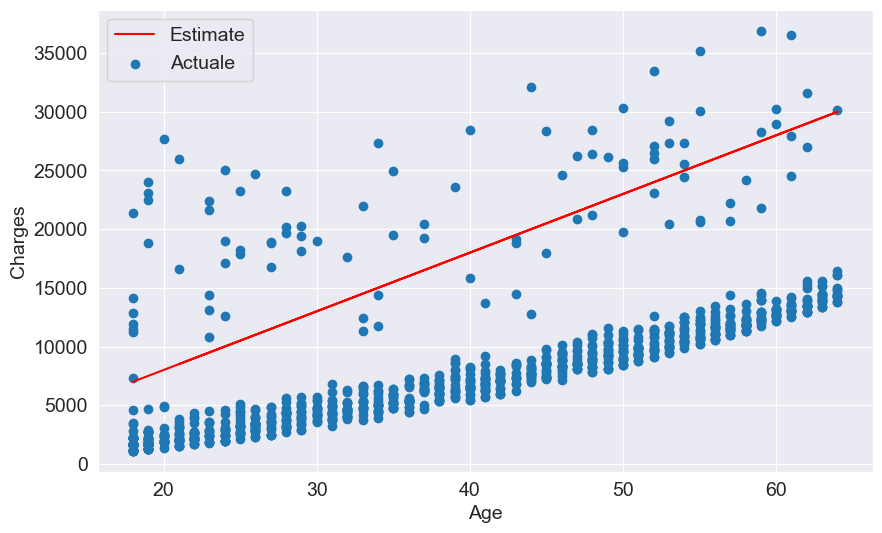

In [50]:
try_parameters(500, -2000)

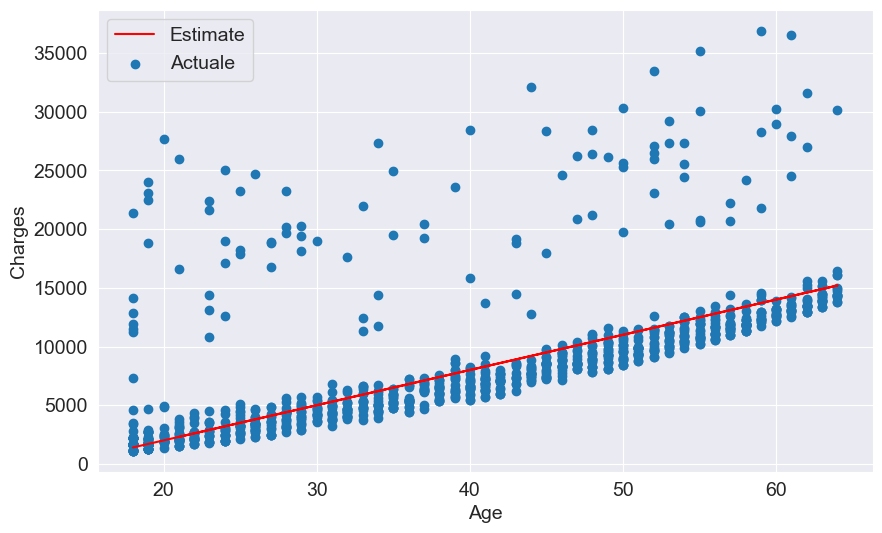

In [51]:
try_parameters(300, -4000)

# Loss/Cost Function

In [53]:
target = no_smoker_df.charges
prediction = estimated_charges

In [54]:
#RMSE : Root Mean Squared Error
#   ما مدى بعدنا عن الخط
#   مدى سوء النموئج بالتنبؤ
#   كلما كان اقل كان النموذج افضل وكلما كان اكبر كان النموذج سيء
#   لاختيار افضل المتحولات بمكن اخذه بالاعتبار بدون الرسوم
def rmse(target, prediction):
    return np.sqrt(np.mean(np.square(target - prediction)))

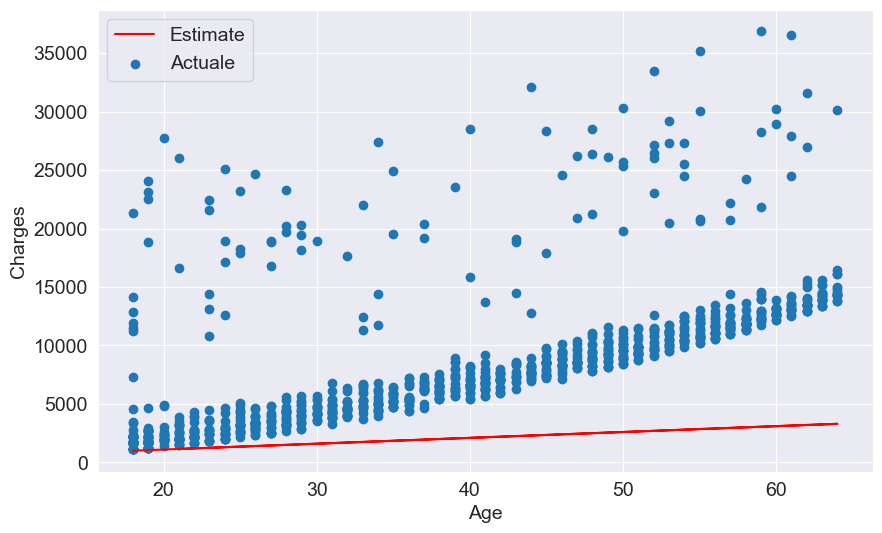

In [55]:
try_parameters(50, 100)

In [56]:
target = no_smoker_df.charges
prediction = estimate_charges(no_smoker_df.age, 50, 100)
rmse(target, prediction)
#   ان قيمه الخطا كبيره بحيث للاشخاص الذين يتحملون نفقات رخيصه فهو كبير جدا هذا الخطا حتى مع الاشخاص الذين يتحملون نفقات كبيره

8461.949562575493

In [57]:
target = no_smoker_df.charges
prediction = estimate_charges(no_smoker_df.age, 300, -4000)
rmse(target, prediction)
#   

4725.9133994520325

In [58]:
def tray_parameter(w, b):
    ages = no_smoker_df.age
    target = no_smoker_df.charges
    prediction = estimate_charges(ages, w, b)
    plt.plot(ages, prediction, color = 'red')
    plt.scatter(ages, target)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actuale'])

    loss = rmse(target, prediction)
    print("RMSE Loss: ", loss)

RMSE Loss:  8461.949562575493


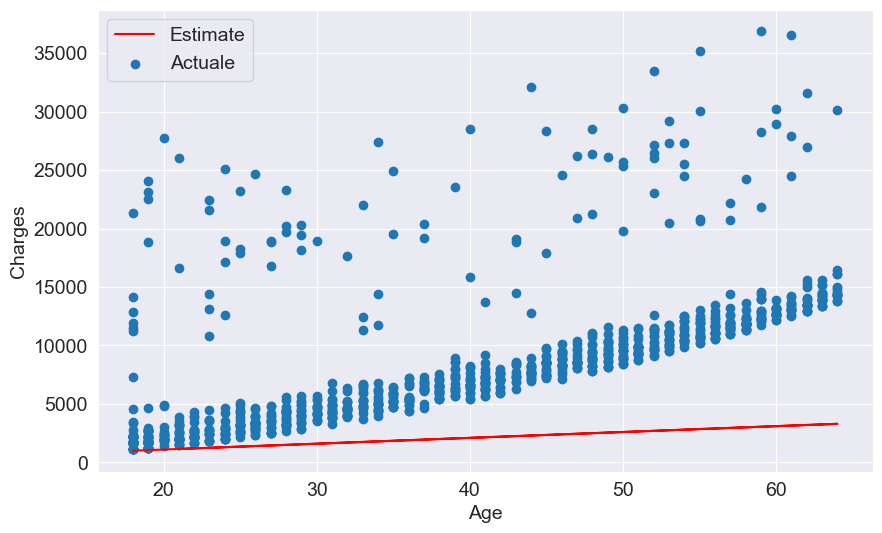

In [59]:
tray_parameter(50, 100)

RMSE Loss:  4991.993804156943


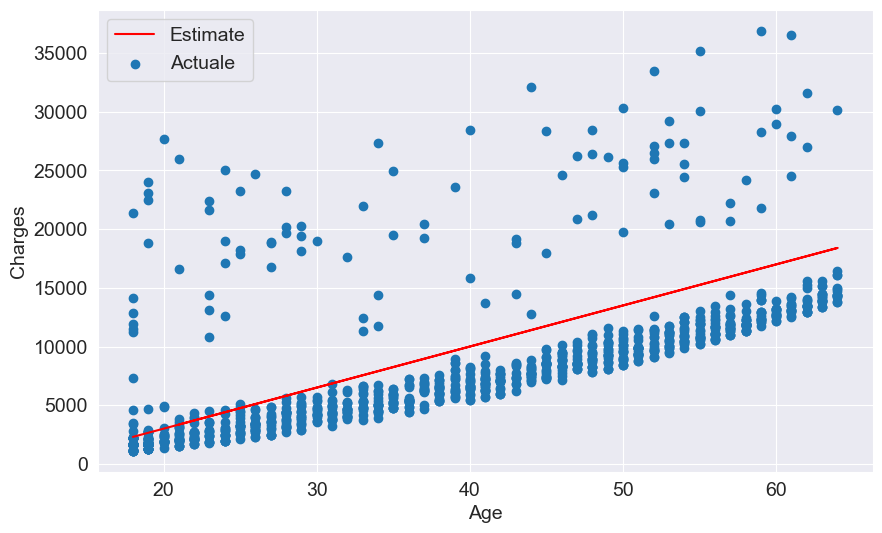

In [60]:
tray_parameter(350, -4000)

In [61]:
#    لاختيار افضل المعلمات الت تقلل تابع الخساره نستخدم تقنيتين
#  1- Ordinary Least Squares :   مفيده اذا كانت البيانات صغيره
#  2- Stochastic gradient descent:   مفيده اذا كانت البيانات كبيره

# Linear Regression using Scikit_learn

In [63]:
from sklearn.linear_model import LinearRegression
# class

In [64]:
model = LinearRegression()
# object

In [65]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [66]:
input = no_smoker_df[['age']]
target = no_smoker_df.charges
print("input.shape", input.shape)
print("target.shape", target.shape)

input.shape (1064, 1)
target.shape (1064,)


In [67]:
model.fit(input, target)

LinearRegression()

In [68]:
model.predict(np.array([[23],[37],[61]]))

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [69]:
prediction = model.predict(input)
prediction

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [70]:
target

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [71]:
rmse (target, prediction)
#   نلاحظ ان المودل يخطا فقط ب 2000 او 1000 فقط ولكن وجود القيم المتطرفه اثرت عليه وهو ليس سيء

4662.505766636395

In [72]:
print("w= ",model.coef_)
print("w= ",model.intercept_)

w=  [267.24891283]
w=  -2091.4205565650827


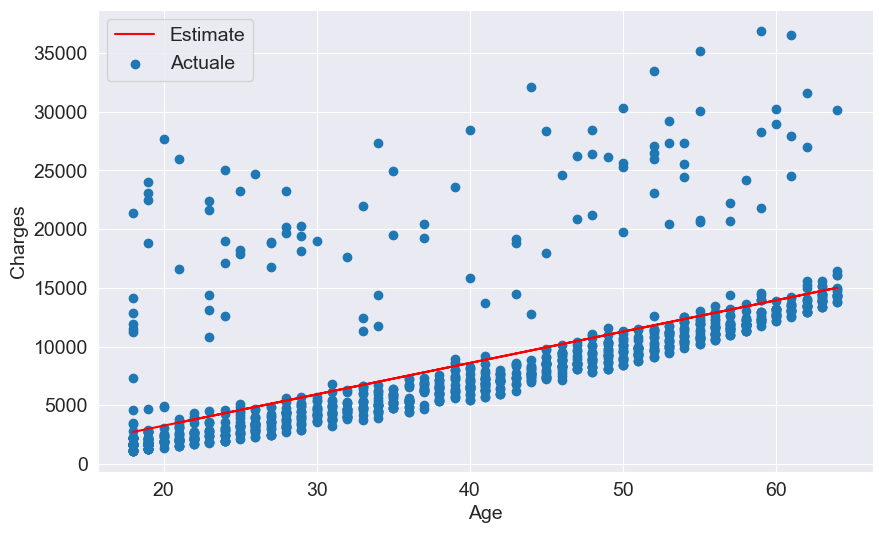

In [73]:
try_parameters(model.coef_, model.intercept_)

In [74]:
#SGDRegressor : Stochastic Gradient Descent (SGD)
from sklearn.linear_model import SGDRegressor

In [75]:
model1 = SGDRegressor()

In [76]:
model1.fit(input, target)

SGDRegressor()

In [77]:
prediction = model1.predict(input)

In [78]:
model1.predict(np.array([[23],[37],[61]]))

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


array([3151.28951987, 4096.82697621, 5717.74832993])

In [79]:
rmse(target, prediction)

6861.784308105834

In [80]:
print("w= ",model1.coef_)
print("w= ",model1.intercept_)

w=  [67.53838974]
w=  [1597.90655589]


In [81]:
prediction

array([2813.59757118, 3488.98146857, 3826.67341726, ..., 2813.59757118,
       2813.59757118, 3016.2127404 ])

In [82]:
target

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [83]:
smoker_df = medical_df[medical_df.smoker == 'yes']
smoker_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


<Axes: xlabel='age', ylabel='charges'>

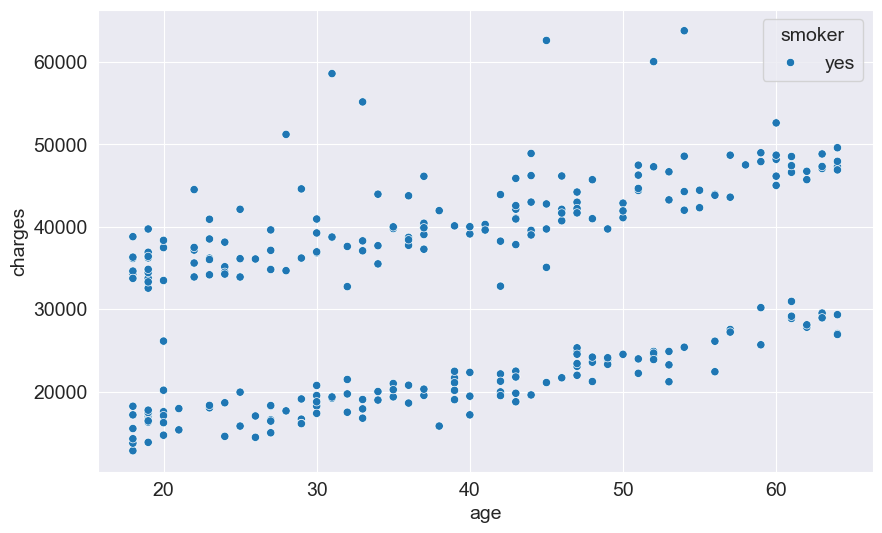

In [84]:
sns.scatterplot(data = smoker_df, x = 'age', y = 'charges', hue = 'smoker')

<Axes: xlabel='age', ylabel='charges'>

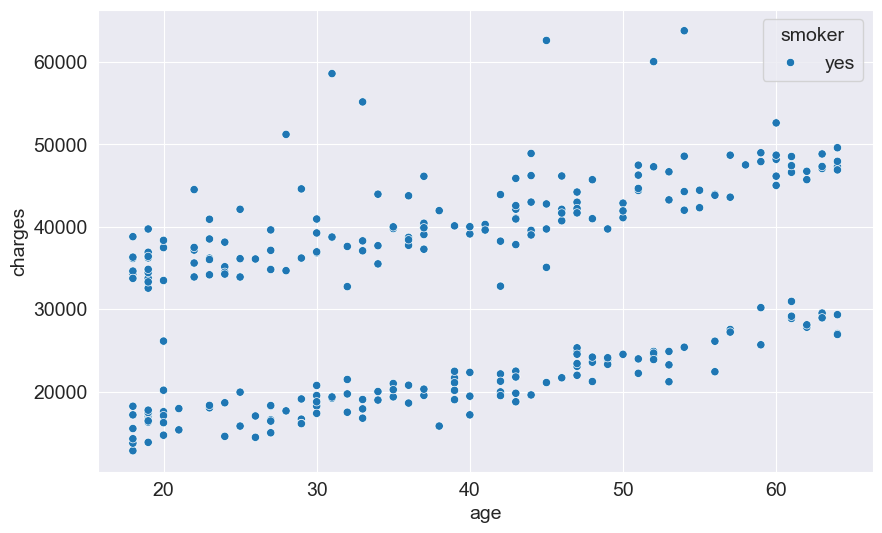

In [85]:
sns.scatterplot(data = smoker_df, x = 'age', y = 'charges', hue = 'smoker')

In [86]:
estimate_charges(22,50, 100)

1200

In [87]:
ages = smoker_df.age
estimated_charges = estimate_charges(ages, 50, 100)

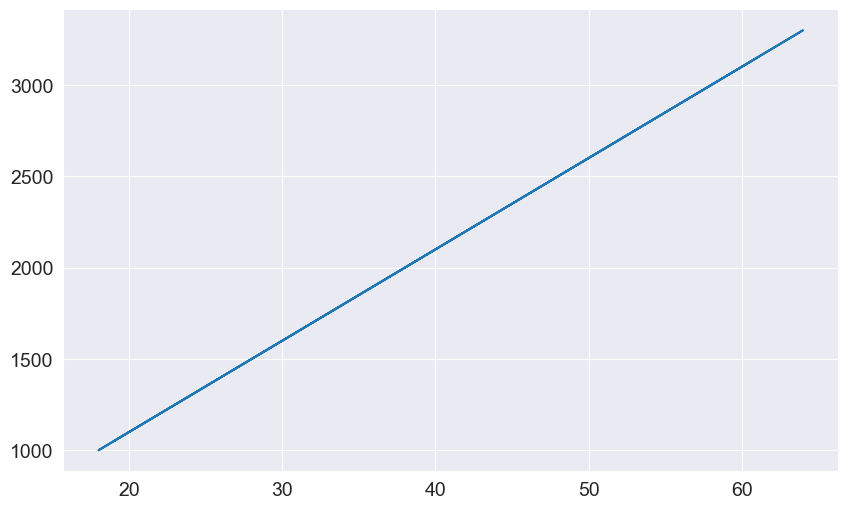

In [88]:
plt.plot(ages,estimated_charges)

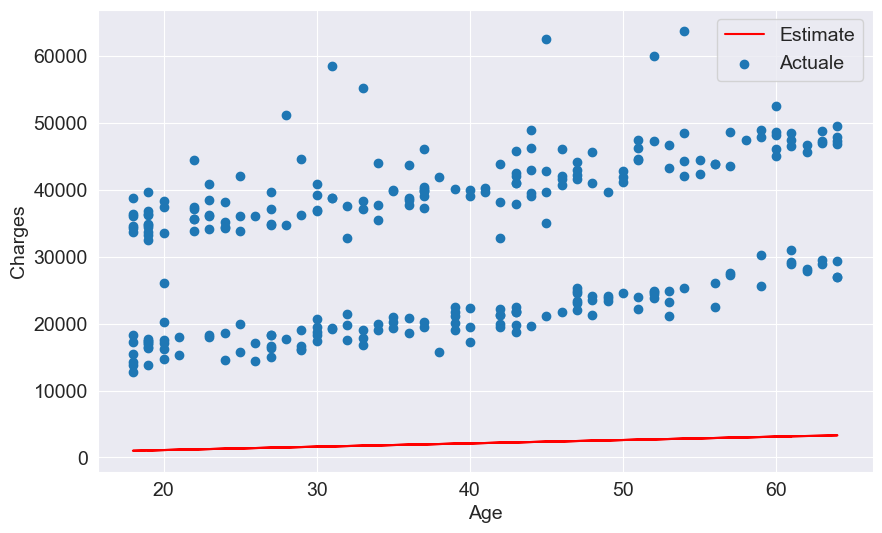

In [89]:
plt.plot(ages, estimated_charges, color = 'red')
plt.scatter(ages, smoker_df.charges)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actuale'])

In [90]:
def tray_parameter(w, b):
    ages = smoker_df.age
    target = smoker_df.charges
    prediction = estimate_charges(ages, w, b)
    plt.plot(ages, prediction, color = 'red')
    plt.scatter(ages, target)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actuale'])
    loss = rmse(target, prediction)
    print("RMSE Loss: ", loss)

RMSE Loss:  11049.661530707117


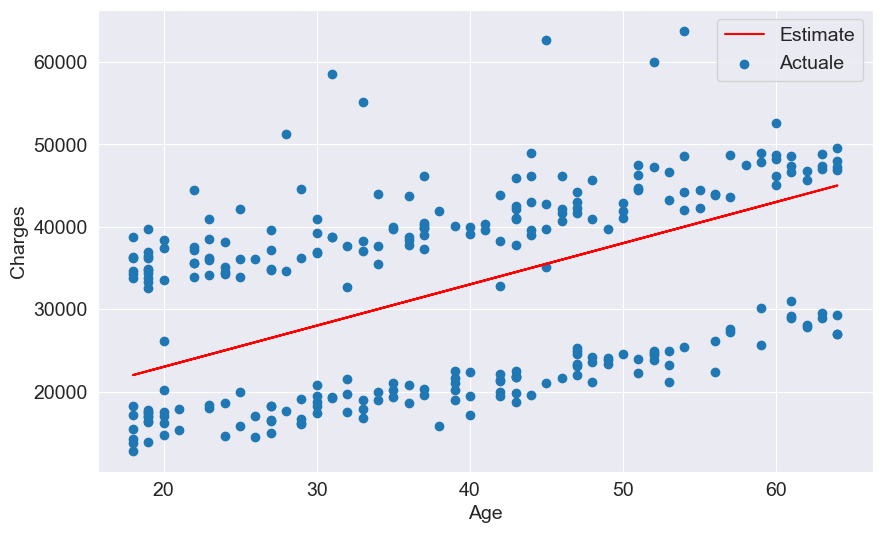

In [91]:
tray_parameter(500, 13000)

In [92]:
input = smoker_df[['age']]
target = smoker_df.charges
print("input.shape", input.shape)
print("target.shape", target.shape)

input.shape (274, 1)
target.shape (274,)


In [93]:
model.fit(input, target)

LinearRegression()

In [94]:
model.predict(np.array([[23],[37],[61]]))

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([27314.59297544, 31587.91940498, 38913.62185562])

In [95]:
target

0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

In [96]:
prediction = model.predict(input)
prediction

array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865, 29756.49379232, 27009.35537333, 28840.78098599,
       30977.44420076, 38608.38425351, 31282.68180287, 34945.53302819,
       31282.68180287, 37997.90904929, 25788.40496489, 36471.72103874,
       26398.88016911, 28840.78098599, 28535.54338388, 27009.35537333,
       31587.91940498, 34029.82022186, 37692.67144718, 38303.1466514 ,
       39829.33466195, 37387.43384507, 31893.15700709, 38913.62185562,
       26398.88016911, 39524.09705984, 29146.0185881 , 33724.58261975,
       26093.642567  , 30061.73139443, 30672.20659865, 29451.25619021,
       34335.05782397, 33114.10741553, 34945.53302819, 25788.40496489,
       29451.25619021, 33114.10741553, 25788.40496489, 39524.09705984,
       31282.68180287, 28535.54338388, 30977.44420076, 26093.642567  ,
       33114.10741553, 32503.63221131, 26093.642567  , 27314.59297544,
       39524.09705984, 25788.40496489, 39524.09705984, 36776.95864085,
      

In [97]:
rmse (target, prediction)

10711.00334810241

In [98]:
print("w= ",model.coef_)
print("w= ",model.intercept_)

w=  [305.23760211]
w=  20294.128126915966


RMSE Loss:  10711.00334810241


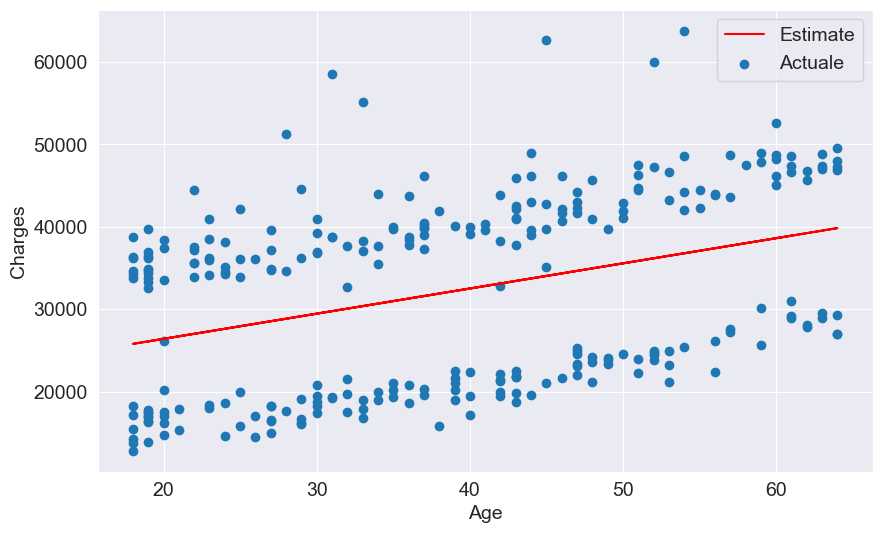

In [99]:
tray_parameter(model.coef_, model.intercept_)

In [100]:
model1.fit(input, target)

SGDRegressor()

In [101]:
prediction = model1.predict(input)

In [102]:
rmse(target, prediction)

2642108399.5229397

In [103]:
print("w= ",model1.coef_)
print("w= ",model1.intercept_)

w=  [4005226.83998289]
w=  [-2.79574972e+09]


- Machine Learning:
 - Model
 - Cost Function
 - Optimizer

1) Create input and target
2) Create and train the model
3) Generate predictions
4) Compute loss to evalute the model

# 2- Linear Regression using Multiple Features

In [106]:
# Charges = w1 * age + w2 * bmi +b
input, target = no_smoker_df[['age', 'bmi']], no_smoker_df['charges']
model = LinearRegression().fit(input, target)
prediction = model.predict(input)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", model.coef_)
print("b=", model.intercept_)
#  صغير جدا لذالك ليس له تاثير BMI  وزن 
#  لا يمكن ايجاد علاقه غير موجده عندما تطبق اي مودل اة تحسنه

Loss:  4662.3128354612945
w= [266.87657817   7.07547666]
b= -2293.6320906488672


In [107]:
#  لم يحدث تي تاثير لانه به علاقه ارتباط ضعيفه جدا
no_smoker_df.charges.corr(no_smoker_df.bmi)

0.08403654312833272

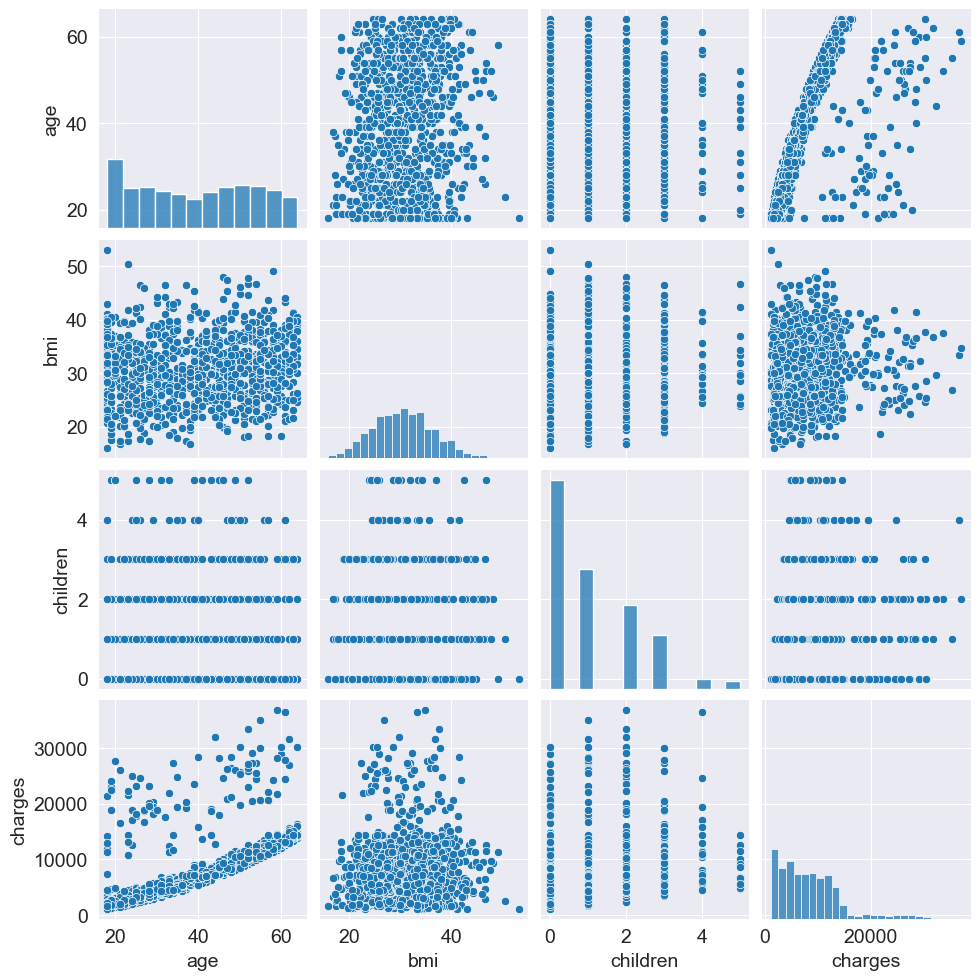

In [108]:
sns.pairplot(data = no_smoker_df)
#   نلاحظ عدم وجد خط يمكن تمثيل البيانات فهي تتنشر 

In [109]:
# Charges = w1 * age + w2 * bmi +W3 * children +b
no_smoker_df.charges.corr(no_smoker_df.children)

0.138928704535422

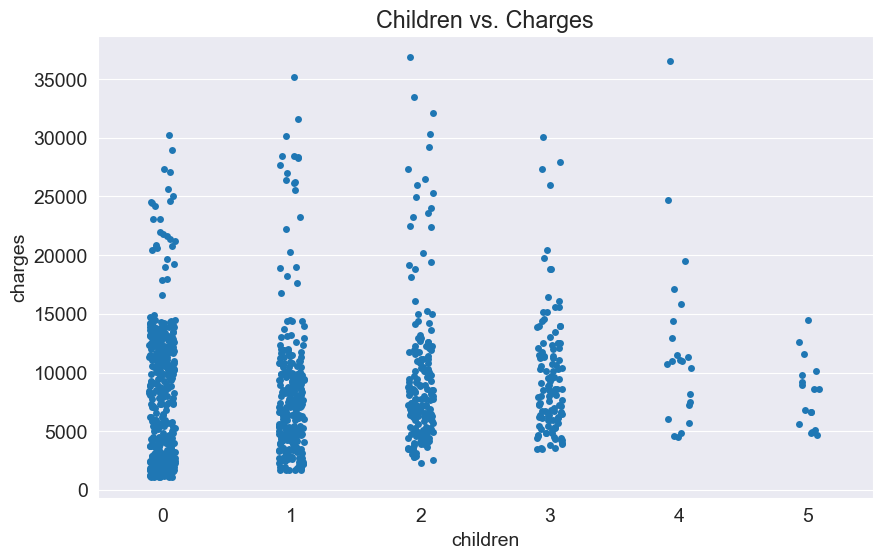

In [110]:
sns.stripplot(data = no_smoker_df, x = 'children', y = 'charges',  marker ='o')
plt.title("Children vs. Charges")
plt.show()

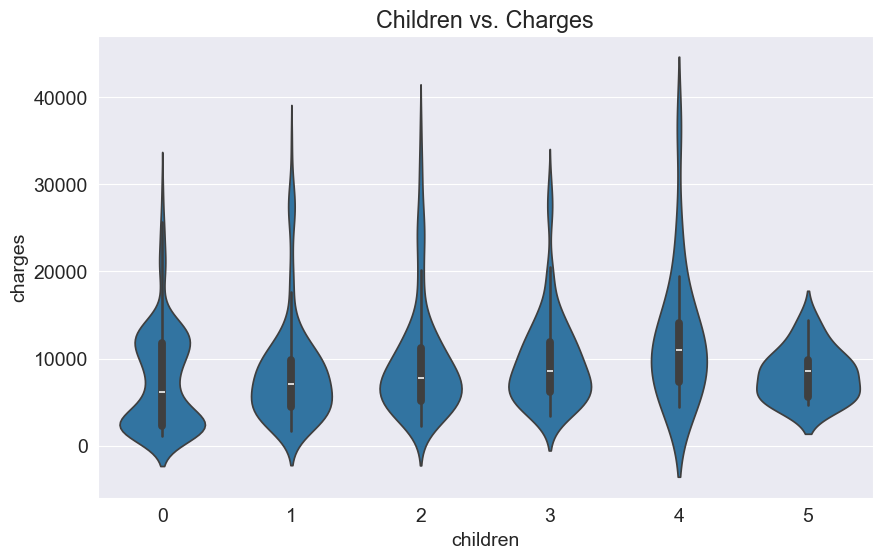

In [111]:
sns.violinplot(data = no_smoker_df, x = 'children', y = 'charges')
plt.title("Children vs. Charges")
plt.show()

In [112]:
input, target = no_smoker_df[['age', 'bmi', 'children']], no_smoker_df['charges']
model = LinearRegression().fit(input, target)
prediction = model.predict(input)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", model.coef_)
print("b=", model.intercept_)

Loss:  4608.470405038246
w= [265.2938443    5.27956313 580.65965053]
b= -2809.2976032235892


In [113]:
input, target = smoker_df[['age', 'bmi', 'children']], smoker_df['charges']
model = LinearRegression().fit(input, target)
prediction = model.predict(input)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", model.coef_)
print("b=", model.intercept_)

Loss:  5718.202480524154
w= [ 264.93316919 1438.72926245  198.88027911]
b= -22556.088196491593


In [114]:
input, target = medical_df[['age', 'bmi', 'children']], medical_df['charges']
model = LinearRegression().fit(input, target)
prediction = model.predict(input)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", model.coef_)
print("b=", model.intercept_)

Loss:  11355.317901125973
w= [239.99447429 332.0833645  542.86465225]
b= -6916.243347787033


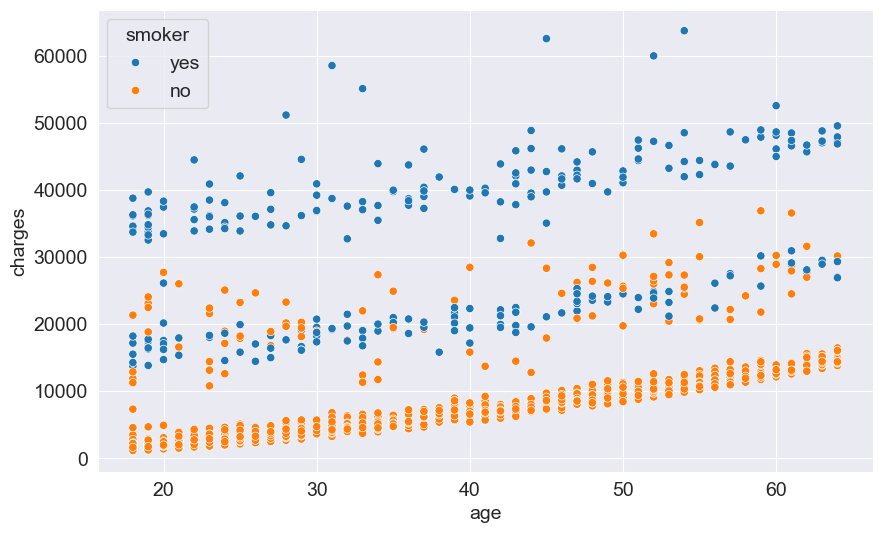

In [115]:
sns.scatterplot(data = medical_df, x = 'age', y = 'charges', hue = 'smoker');

# Using Categorical Features for Mathin Learning

# 1) Binary Categorical

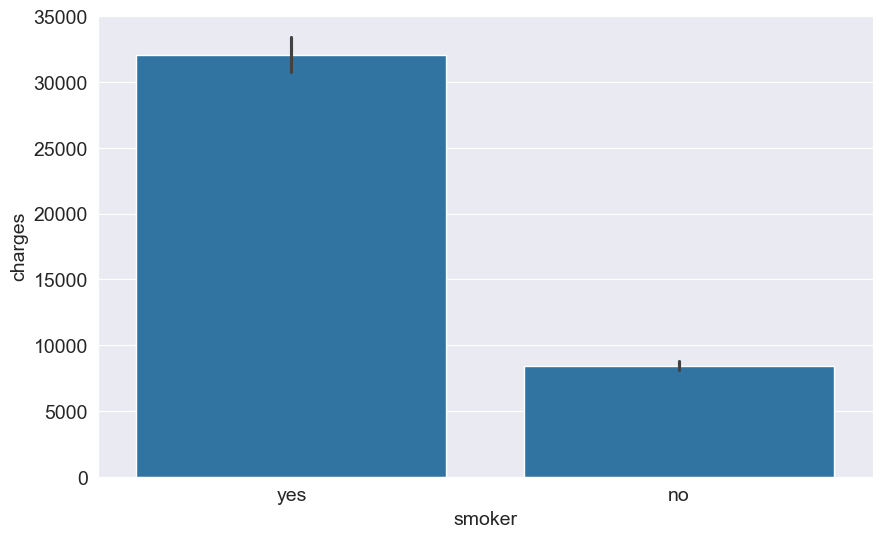

In [118]:
sns.barplot(data = medical_df, x = 'smoker', y = 'charges');

In [119]:
smoker_code = {'no' : 0, 'yes' : 1}
medical_df['smoker_code'] = medical_df['smoker'].map(smoker_code)

In [120]:
medical_df.charges.corr(medical_df.smoker_code)

0.7872514304984772

In [121]:
# Charges = w1 * age + w2 * bmi +W3 * children + w4 * smoker_code + b
input, target = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']
model = LinearRegression().fit(input, target)
prediction = model.predict(input)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", model.coef_)
print("b=", model.intercept_)
#   انه ليس افصل من قيم غير المدخنين ولكنه افضل من قيم السابقه عند استخدام جميع البيانات

Loss:  6056.439217188081
w= [  257.84950728   321.85140247   473.50231561 23811.3998446 ]
b= -12102.769362727904


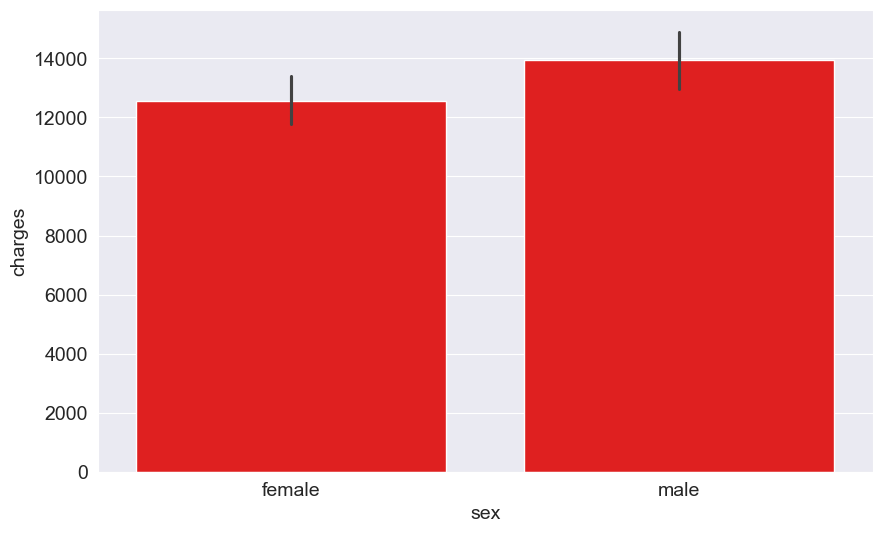

In [122]:
sns.barplot(data = medical_df, x = 'sex', y = 'charges', color = 'red');

In [123]:
sex_code = {'male' : 0, 'female' : 1}
medical_df['sex_code'] = medical_df['sex'].map(sex_code)

In [124]:
medical_df.charges.corr(medical_df.sex_code)

-0.05729206220202542

In [125]:
# Charges = w1 * age + w2 * bmi +W3 * children + w4 * smoker_code + w5 * sex_code + b
input, target = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']
model = LinearRegression().fit(input, target)
prediction = model.predict(input)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", model.coef_)
print("b=", model.intercept_)
#   نلاحظ عدم وجود اي تغيير لذالك يمكن تجاهل عمود الجنس وان التغيير الطفيف هو اقل من دولار للمتوسط

Loss:  6056.100708754546
w= [  257.73498767   322.36421449   474.41112061 23823.39253065
   128.63985357]
b= -12181.101839234441


# 2) One-hot Encoding

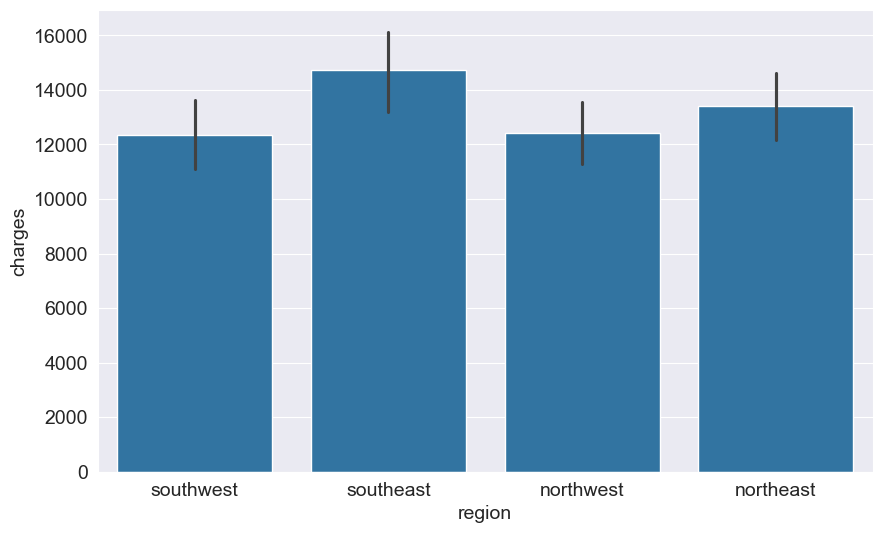

In [127]:
sns.barplot(data = medical_df, x = 'region', y = 'charges');

In [128]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_      

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [129]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [130]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot

In [131]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,1,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,0,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,0,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,0,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,1,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,1,0.0,0.0,0.0,1.0


In [132]:
# Charges = w1 * age + w2 * bmi +W3 * children + w4 * smoker_code + w5 * sex_code + w6 * region + b
input, target = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']], medical_df['charges']
model = LinearRegression().fit(input, target)
prediction = model.predict(input)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", model.coef_)
print("b=", model.intercept_)

Loss:  6041.6796511744515
w= [  256.85635254   339.19345361   475.50054515 23848.53454191
   131.3143594    587.00923503   234.0453356   -448.01281436
  -373.04175627]
b= -12656.862170590557


In [133]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
medical_df[input_cols].loc[10]

age            25.00
bmi            26.22
children        0.00
smoker_code     0.00
sex_code        0.00
northeast       1.00
northwest       0.00
southeast       0.00
southwest       0.00
Name: 10, dtype: float64

In [134]:
model.predict([[28, 30, 2, 1, 1, 0, 1, 0, 0]])
#  الزبون سوف يخبرنا لماذا تخبرني انه هذه سوف تكةن تكلفه التامين

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([29875.81463599])

# Model Improvements
- Feature Scaling
- Charges = w1 * age + w2 * bmi +W3 * children + w4 * smoker_code + w5 * sex_code + w6 * region + b


In [136]:
print("w=", model.coef_)
print("b=", model.intercept_)
#  يمكن اخبار الزبون انه نطبق وزن عالي للمدخنين

w= [  256.85635254   339.19345361   475.50054515 23848.53454191
   131.3143594    587.00923503   234.0453356   -448.01281436
  -373.04175627]
b= -12656.862170590557


In [137]:
input_cols

['age',
 'bmi',
 'children',
 'smoker_code',
 'sex_code',
 'northeast',
 'northwest',
 'southeast',
 'southwest']

In [138]:
#weight_df = pd.DataFrame({
#    'feature' : medical_df[input_cols].columns,
#    'weigh' : model.coef_
#})
#weight_df

weight_df = pd.DataFrame({
    'feature' : np.append(input_cols, 1),
    'weigh' : np.append(model.coef_, model.intercept_)
})
weight_df
#   نلاحظ ان وزن مؤشر الجسم والاطفال اعلى من العمر وهذا يتعارض مع مقهومنا كون العمر اعلى اهميه منهم
#   المشكله تكمن ان قيم اعمده يمكن ان تتفاوت مثلا عامود اكبر من قيم هامود اخر وهذا شيء سيء وسؤثر على تابع الخساره
#   اذا كامنت قيم عامود كبيره وغير متناسبه مع تابع الخساره, عند تحديث المودل فالتحسين سيكون لصالح هذا العامود فقط
#   لتوحيد القيم بين 1 و -1 او بين -2 و 2  standarization   لذالك نستخدم 


,feature,weigh
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12656.862171


In [139]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [140]:
print(scaler.mean_) #  حساب المتوسط لكل عامود
print(scaler.var_)  #  حساب التباين لكل عامود

[39.20702541 30.66339686  1.09491779]
[197.25385199  37.16008997   1.45212664]


In [141]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [142]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values
categorical_data

array([[1., 1., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 1.],
       [1., 1., 0., 1., 0., 0.]])

In [143]:
inputs = np.concatenate((scaled_inputs, categorical_data),axis = 1)
inputs

array([[-1.43876426, -0.45332   , -0.90861367, ...,  0.        ,
         0.        ,  1.        ],
       [-1.50996545,  0.5096211 , -0.07876719, ...,  0.        ,
         1.        ,  0.        ],
       [-0.79795355,  0.38330685,  1.58092576, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367, ...,  0.        ,
         1.        ,  0.        ],
       [-1.29636188, -0.79781341, -0.90861367, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.55168573, -0.26138796, -0.90861367, ...,  1.        ,
         0.        ,  0.        ]])

In [144]:
target = medical_df.charges
z = LinearRegression().fit(inputs, target)
prediction = z.predict(inputs)
loss = rmse(target, prediction)
print("Loss: ", loss)
print("w=", z.coef_)
print("b=", z.intercept_)
#   وجدنا انه لا يؤثر على تابع الخساره

Loss:  6041.6796511744515
w= [ 3607.47273619  2067.69196584   572.99820995 23848.53454191
   131.3143594    587.00923503   234.0453356   -448.01281436
  -373.04175627]
b= 8335.16885601673


In [145]:
weight_df = pd.DataFrame({
    'feature' : np.append(numeric_cols+cat_cols, 1),
    'weight' : np.append(model.coef_, model.intercept_)
})
weight_df.sort_values('weight', ascending= False)

,feature,weight
3,smoker_code,23848.534542
5,northeast,587.009235
2,children,475.500545
1,bmi,339.193454
0,age,256.856353
6,northwest,234.045336
4,sex_code,131.314359
8,southwest,-373.041756
7,southeast,-448.012814
9,1,-12656.862171


In [146]:
new_customers = [[28, 30, 2, 1, 1, 0, 1, 0, 0]]
scaler.transform([[28, 30, 2]])

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.79795355, -0.10882659,  0.75107928]])

In [147]:
new_customers = [[-0.79795355, -0.10882659,  0.75107928, 1, 1, 0, 1, 0, 0]]
model.predict(new_customers)

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11672.29796816])

# How to approach a machine learning problem
-  استكشاف البيانات والعثور على الارتباطات المختلفه بين المدخلات والاهداف
-  نختار المودل الصحيح
-  نقوم بقياس المتغيرات الرقميه وتحويل الفئات
-  تخصيص مجموعه اختبار
-  تدريب المودل
-  التنبا وحساب تابع الخساره

# 2- Logistic Regression With Scikit Learn

- Logistic Regression vs. Linear Regression
- Logistic Regression :  هو جيد للتصنيف خاصه اذا كانت انحدار وهو خوارزميه تصنيف
- Logistic Regression :  ناخذ المعادله ونجعلها من صفر لواحد ومن ثم نستنتج القيمه التي حصلنا عليها من داله سجما كاحتمال للفئه التي نحاول التنبا بها
- ثم ياخذ الاحتمالات ويقارنها بالبيانات

In [150]:
!pip install opendatasets --upgrade --quiet

In [151]:
import opendatasets as od

In [152]:
od.version()

'0.1.22'

In [153]:
dataset_url = 'https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package'

In [154]:
od.download(dataset_url)
#   عند طلب اسم المستخدم والمفتاح اما نذهب لكاقل ونعمل مفتاح جديد من حساب وننزل ملف جيسون وننسخه منه
#   او نقوم بتحميل ملف جيسون لجوبيتور وهو ينسخ الاسم والمفتاح تلقائيا

Skipping, found downloaded files in ".\weather-dataset-rattle-package" (use force=True to force download)


In [155]:
import os
data_dir = './weather-dataset-rattle-package'
os.listdir(data_dir)
train_csv = data_dir + '/weatherAUS.csv'
train_csv

'./weather-dataset-rattle-package/weatherAUS.csv'

In [156]:
raw_df = pd.read_csv(train_csv)
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [157]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [158]:
raw_df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [159]:
raw_df[['RainToday','RainTomorrow']].isnull().sum()

RainToday       3261
RainTomorrow    3267
dtype: int64

In [160]:
raw_df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [161]:
raw_df['RainToday'].value_counts()

RainToday
No     110319
Yes     31880
Name: count, dtype: int64

In [162]:
raw_df.isnull().any(axis=0)

Date             False
Location         False
MinTemp           True
MaxTemp           True
Rainfall          True
Evaporation       True
Sunshine          True
WindGustDir       True
WindGustSpeed     True
WindDir9am        True
WindDir3pm        True
WindSpeed9am      True
WindSpeed3pm      True
Humidity9am       True
Humidity3pm       True
Pressure9am       True
Pressure3pm       True
Cloud9am          True
Cloud3pm          True
Temp9am           True
Temp3pm           True
RainToday         True
RainTomorrow      True
dtype: bool

In [163]:
raw_df.dropna(subset = ['RainTomorrow', 'RainToday'], inplace= True)

In [164]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  object 
 1   Location       140787 non-null  object 
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  object 
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  object 
 10  WindDir3pm     137117 non-null  object 
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   fl

# Exploring Data Analysis and Visualization
من الجيد معرفه توزيع الاعمده وارتباطها بالعامود الهدف

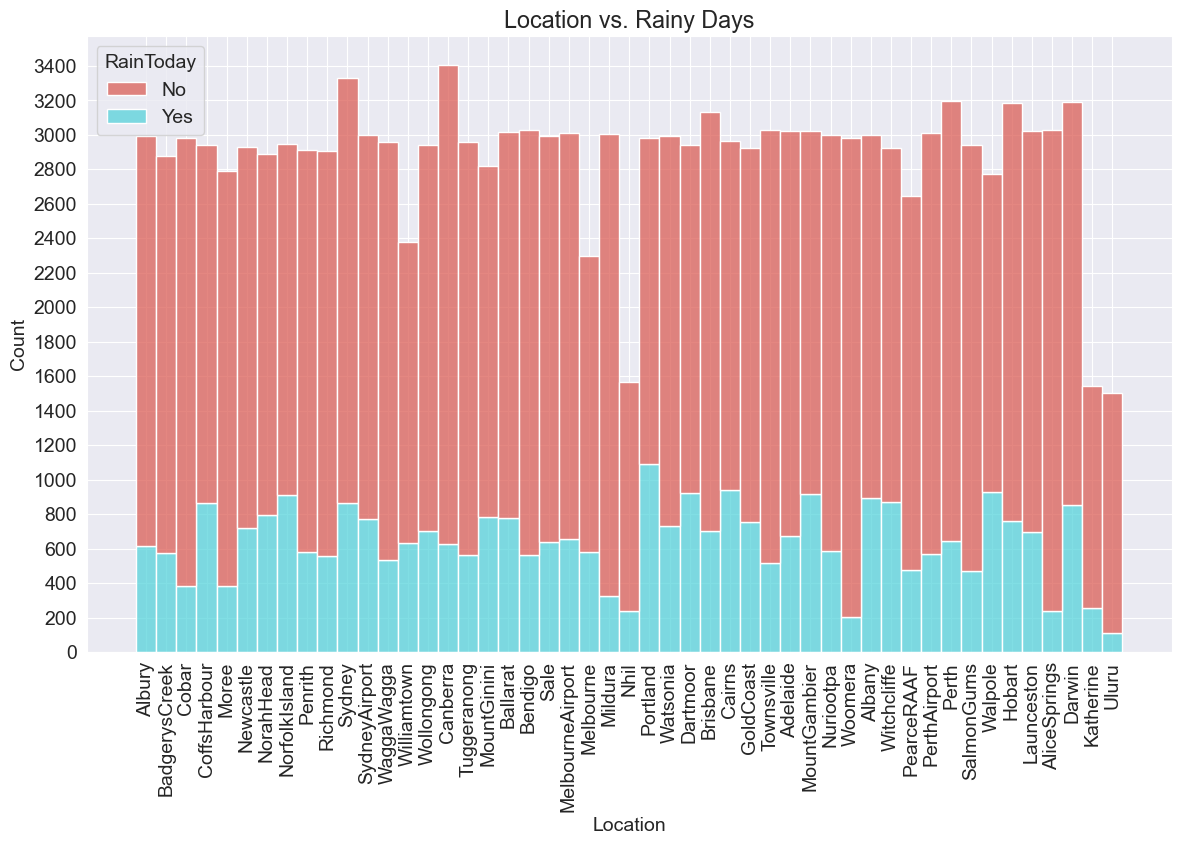

In [166]:
plt.figure(figsize = (14, 8))
sns.histplot(data = raw_df, x = 'Location', hue = 'RainToday', palette = 'hls', multiple = 'stack')
plt.title('Location vs. Rainy Days')
plt.xticks(rotation = 90)
plt.yticks(range(0,3500,200))
plt.show()
#  نلاحظ ان البيانات متوازنه مع بعض المدن التي من الممكن لن تكن لديها محطات الطقس او فقدو بيانات 

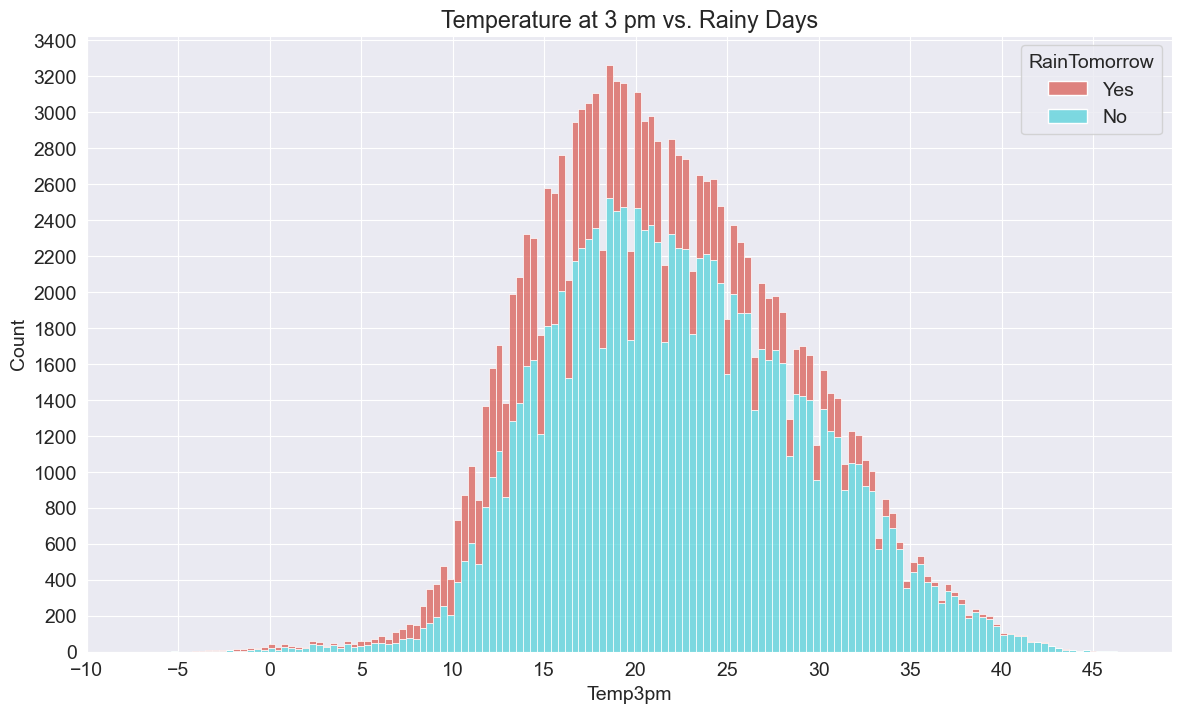

In [167]:
plt.figure(figsize = (14, 8))
sns.histplot(data = raw_df, x = 'Temp3pm', hue = 'RainTomorrow', hue_order = ['Yes', 'No'], palette = 'hls', multiple = 'stack')
plt.title('Temperature at 3 pm vs. Rainy Days')
plt.xticks(range(-10,50,5))
plt.yticks(range(0,3500,200))
plt.show()
#  اذا كانت درجه الحراره منخفضه غاحتمال ان تهطل الامطار

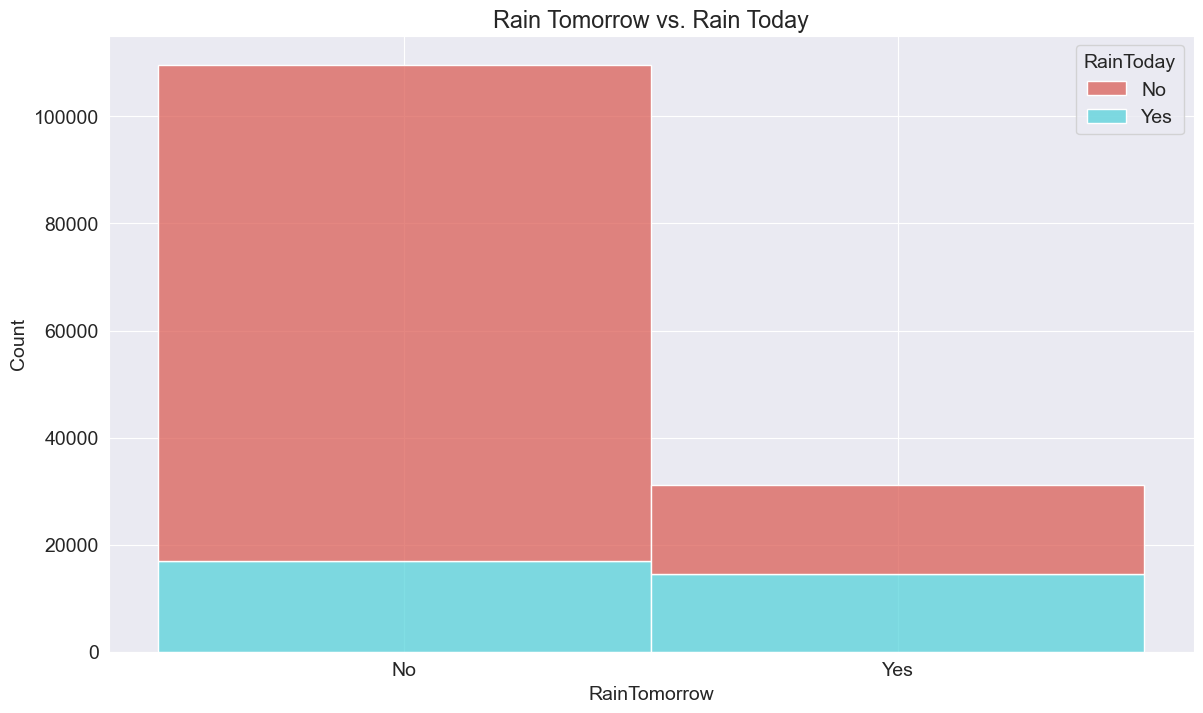

In [168]:
plt.figure(figsize = (14, 8))
sns.histplot(data = raw_df, x = 'RainTomorrow', hue = 'RainToday', palette = 'hls', multiple = 'stack')
plt.title('Rain Tomorrow vs. Rain Today')
plt.show()
#  نلاحظ وجود عدم توازن في البيانات
#  نلاحظان اذا لم يهطل المطر اليوم فغالبا لم يهطل غطا
#  التنبؤ بهطل المطر غدا هو صعب

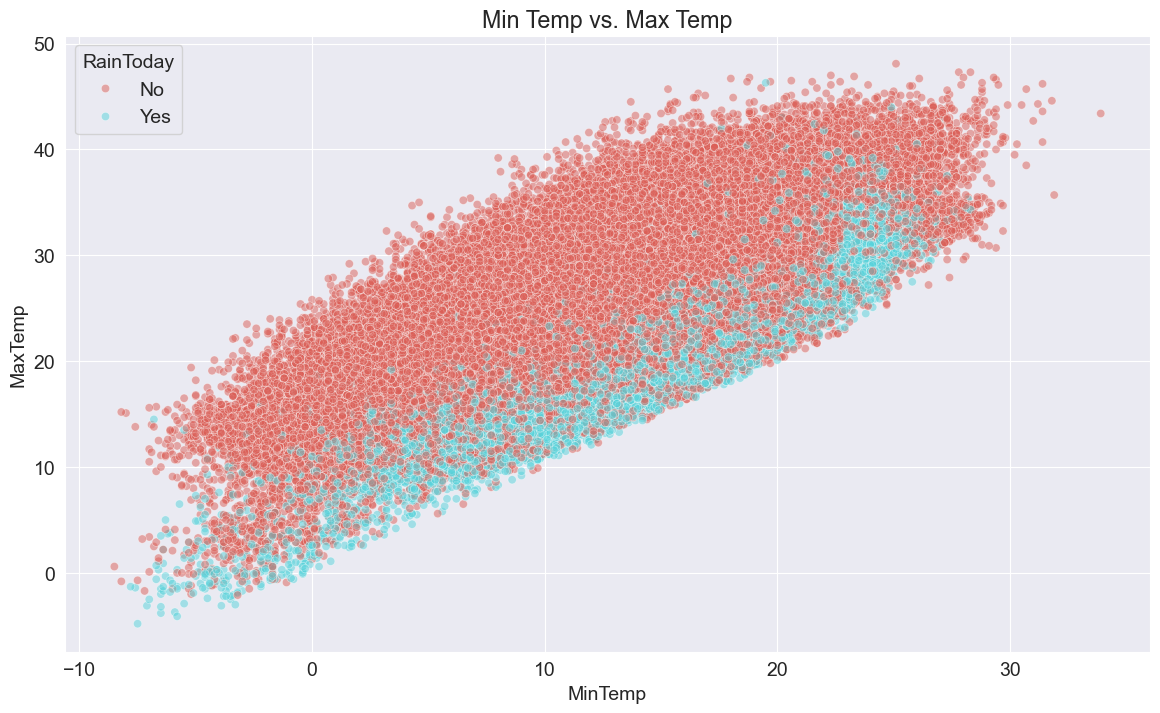

In [169]:
plt.figure(figsize = (14, 8))
sns.scatterplot(data = raw_df, x = 'MinTemp', y = 'MaxTemp', hue ='RainToday', palette = 'hls', alpha = 0.5)
plt.title('Min Temp vs. Max Temp')
plt.show()
#   عندما تمطر في يوم معين فان الاختلاف في درجات الحراره يكون صغير

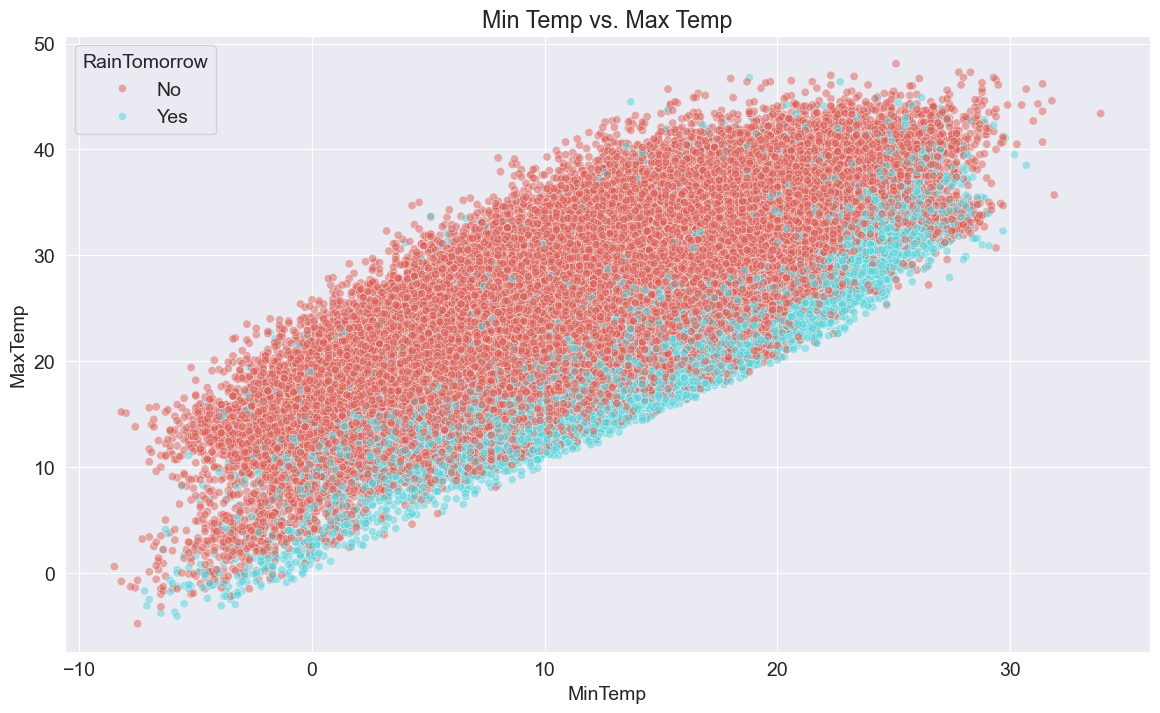

In [170]:
plt.figure(figsize = (14, 8))
sns.scatterplot(data = raw_df, x = 'MinTemp', y = 'MaxTemp', hue ='RainTomorrow', palette = 'hls', alpha = 0.5)
plt.title('Min Temp vs. Max Temp')
plt.show()

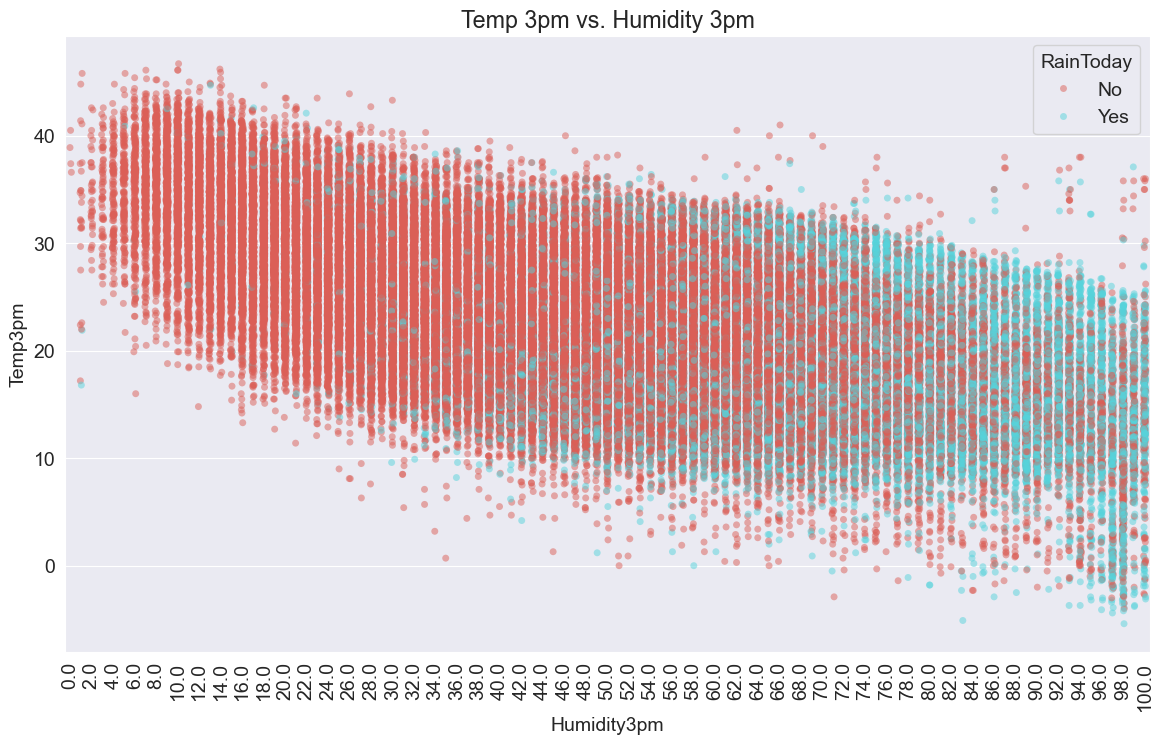

In [171]:
plt.figure(figsize = (14, 8))
sns.stripplot(data = raw_df, x = 'Humidity3pm', y = 'Temp3pm', hue ='RainToday', palette = 'hls', alpha = 0.5)
plt.title('Temp 3pm vs. Humidity 3pm')
plt.xticks(range(0,101,2),rotation = 90)
plt.show()

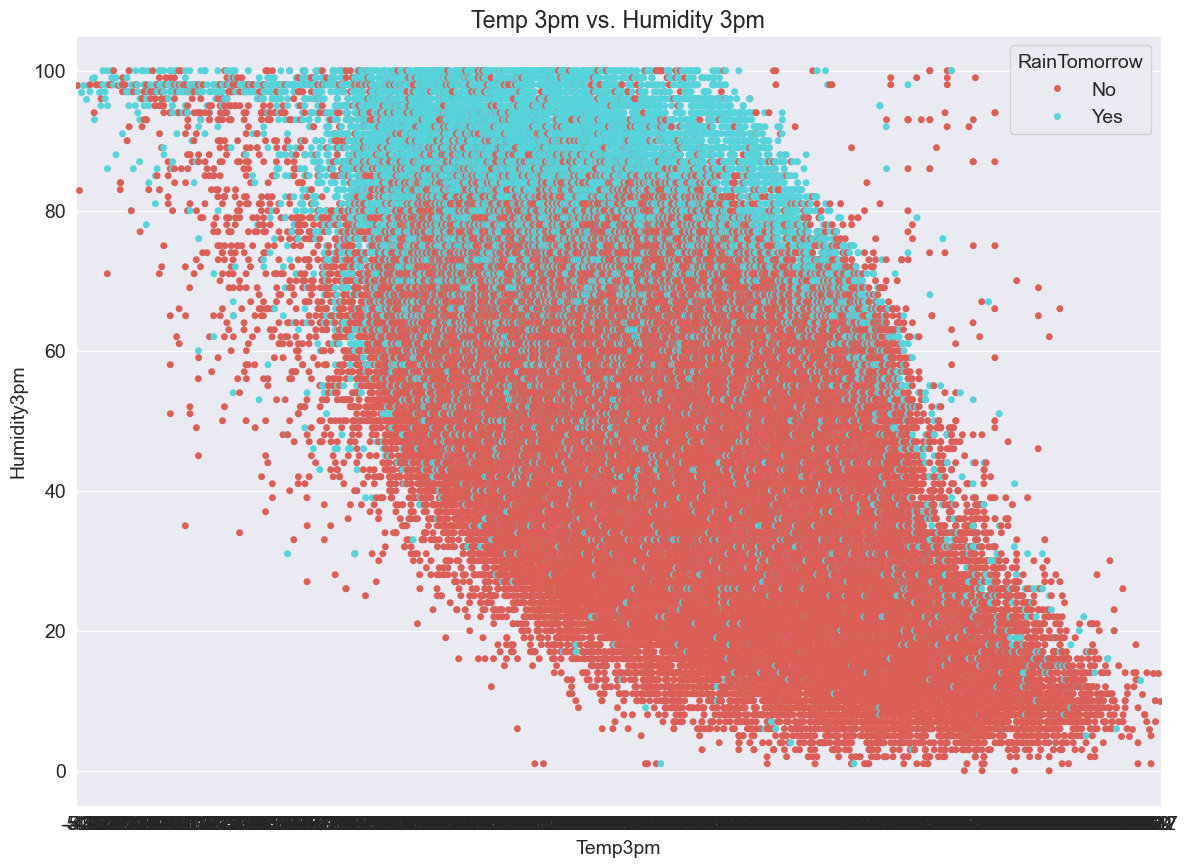

In [172]:
plt.figure(figsize = (14, 10))
sns.stripplot(data = raw_df, x = 'Temp3pm', y = 'Humidity3pm', hue ='RainTomorrow', palette = 'hls')
plt.title('Temp 3pm vs. Humidity 3pm')
plt.show()
#   اذا كانت درجه الحراره منخفضه والرطوبه مرتفعه قد يهطل الامطار غدا

# (Optional) Working with a Sample
      عند وجود بيانات ضخمه ملايين من الصفوف يمكن في البدايه العمل على عينه لتطبيق الافكار عليها بشكل اسرع وهي عشوائية

In [174]:
use_sample = False
sample_fraction = 0.1
if use_sample:
    raw_df = raw_df.sample(frac = sample_fraction).copt()
#   هنا ناخذ عشره بالمئه من البيانات
#   واذا كان خاطئا نجعل قيمته خطا ونعيد تشغيل الدفتر من البدايه

# Training, Validation and Test Sets
     بيانات التدريب: تستخدم لتدريب النموذج
     بيانات التحقق: تستخدم للتحقق من النموذج بعد تدريبه اي تقييمه لان التدريب يكون على اكثر من خطوه
     بيانات الاختبار: لمقارنه نماذج مختلفه 

     - يمكن استخدام 60 للتدريب و 20 للتحقق و 20 للاختبار مناسب للبيانت بالالاف
     
     - اذا كانت اكثر يمكن تقليل بيانات التحقق والاختبار وزياده بيانات الاختبار

     - اذا اعطيت بيانات منفصله مجموعه اختبار وتدريب يمكن تقسيم التدريب ل 75 ل 25 او 70 ل 30

In [176]:
from sklearn.model_selection import train_test_split

In [177]:
train_val_df, test_df = train_test_split(raw_df, test_size = 0.2, random_state = 42)
train_df, val_df = train_test_split(train_val_df, test_size = 0.25, random_state = 42)

In [178]:
print("train_df.shape :", train_df.shape)
print("val_df.shape :", val_df.shape)
print("test_df.shape :", test_df.shape)

train_df.shape : (84471, 23)
val_df.shape : (28158, 23)
test_df.shape : (28158, 23)


   اذا كانت البيانات سلسله زمنيه فمن الافضل تقسيم البيانات حسب التواريخ لاننا في المودل سوف نعتمد على المستقبل للتنبا


plt.title('No. of Rows per Year')
#   نصل لعامود التواريخ ثم نختار اي شي مثل السنه او الشهر او اليوم
sns.countplot(pd.to_datetime(raw_df.Date).dt.year)

In [181]:
year = pd.to_datetime(raw_df.Date).dt.year
year

0         2008
1         2008
2         2008
3         2008
4         2008
          ... 
145454    2017
145455    2017
145456    2017
145457    2017
145458    2017
Name: Date, Length: 140787, dtype: int32

In [182]:
train_df = raw_df[ year < 2015  ]
val_df   = raw_df[ year == 2015 ]
test_df  = raw_df[ year > 2015  ]

print("train_df.shape :", train_df.shape)
print("val_df.shape :", val_df.shape)
print("test_df.shape :", test_df.shape)

train_df.shape : (97988, 23)
val_df.shape : (17089, 23)
test_df.shape : (25710, 23)


# Identifying Input and Target Columns

In [184]:
#  الاعمده ذات القيم الفريده يجب تجاهلها لانها غير مفيده مثل التاريخ لدينا
#  احيانا توجد اعمده مشتقه من العامود الهدف يجب تجاهله لانه نحن نريد بيانات اليوم وليس غدا مثل كميه الامطار غدا
#  المودل لا يتنبا الا بالمواقع الت يعرفها اذا كنا نريده ان يكون عام اذا يجب حذف عمود الموقع
input_cols = list(train_df.columns)[1 : -1]  # train_df.columns[1 : 22]
target_col = 'RainTomorrow'

In [185]:
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_target = test_df[target_col].copy()

In [186]:
train_df[[target_col]]

,RainTomorrow
0,No
1,No
2,No
3,No
4,No
...,...
144548,No
144549,No
144550,No
144551,No


In [187]:
numeric_cols = train_inputs.select_dtypes(include = 'number').columns.tolist()
categorical_cols = train_inputs.select_dtypes(include = 'object').columns.tolist()

In [188]:
train_inputs.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,97674.000000,97801.000000,97988.000000,61657.000000,57942.000000,91160.000000,97114.000000,96919.000000,96936.000000,96872.000000,88876.000000,88857.000000,63000.000000,61966.000000,97414.000000,97392.000000
mean,12.007831,23.022202,2.372935,5.289991,7.609004,40.215873,14.092263,18.764608,68.628745,51.469547,1017.513734,1015.132352,4.302952,4.410677,16.835126,21.540138
std,6.347175,6.984397,8.518819,3.952010,3.788813,13.697967,8.984203,8.872398,19.003097,20.756113,7.072510,6.997072,2.866634,2.693370,6.404586,6.831612
min,-8.500000,-4.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,979.000000,0.000000,0.000000,-5.900000,-5.100000
25%,7.500000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.800000,1010.400000,1.000000,2.000000,12.200000,16.600000
50%,11.800000,22.400000,0.000000,4.600000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.500000,1015.100000,5.000000,5.000000,16.600000,20.900000
75%,16.600000,27.900000,0.800000,7.200000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.300000,1019.900000,7.000000,7.000000,21.400000,26.200000
max,33.900000,48.100000,371.000000,82.400000,14.300000,135.000000,87.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.100000


In [189]:
train_inputs[categorical_cols].nunique()

Location       49
WindGustDir    16
WindDir9am     16
WindDir3pm     16
RainToday       2
dtype: int64

# Imputing Missing Numeric Data

- التقنيه الاكثر استخداما هي المتوسط
- اذا كانت لدينا الكثير من القيم المفقوده وتخلصنا منها قد نفقد بيانات

In [191]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'mean')
#   لان هناك قيم تؤثر على المتوسط median اذا كان يوجد قيم متطرفه يمكن استبدالها بالمتوسط   

In [192]:
#  للتحقق من المعلمات التي يمكن ان ياخذها
?SimpleImputer

Init signature:
SimpleImputer(
    *,
    missing_values=nan,
    strategy='mean',
    fill_value=None,
    copy=True,
    add_indicator=False,
    keep_empty_features=False,
)
Docstring:     
Univariate imputer for completing missing values with simple strategies.

Replace missing values using a descriptive statistic (e.g. mean, median, or
most frequent) along each column, or using a constant value.

Read more in the :ref:`User Guide <impute>`.

.. versionadded:: 0.20
   `SimpleImputer` replaces the previous `sklearn.preprocessing.Imputer`
   estimator which is now removed.

Parameters
----------
missing_values : int, float, str, np.nan, None or pandas.NA, default=np.nan
    The placeholder for the missing values. All occurrences of
    `missing_values` will be imputed. For pandas' dataframes with
    nullable integer dtypes with missing values, `missing_values`
    can be set to either `np.nan` or `pd.NA`.

strategy : str, default='mean'
    The imputation strategy.

    - If "mean",

In [193]:
raw_df[numeric_cols].isnull().sum()

MinTemp            468
MaxTemp            307
Rainfall             0
Evaporation      59694
Sunshine         66805
WindGustSpeed     9105
WindSpeed9am      1055
WindSpeed3pm      2531
Humidity9am       1517
Humidity3pm       3501
Pressure9am      13743
Pressure3pm      13769
Cloud9am         52625
Cloud3pm         56094
Temp9am            656
Temp3pm           2624
dtype: int64

In [194]:
train_inputs[numeric_cols].isnull().sum()

MinTemp            314
MaxTemp            187
Rainfall             0
Evaporation      36331
Sunshine         40046
WindGustSpeed     6828
WindSpeed9am       874
WindSpeed3pm      1069
Humidity9am       1052
Humidity3pm       1116
Pressure9am       9112
Pressure3pm       9131
Cloud9am         34988
Cloud3pm         36022
Temp9am            574
Temp3pm            596
dtype: int64

In [195]:
#    يقوم بحساب المتوسط ولم يقم بملا اي شيء
imputer.fit(raw_df[numeric_cols])

SimpleImputer()

In [196]:
#    يخرج لنا قيم المتوسط التي قام بحسابها
imputer.statistics_

array([  12.18482387,   23.2351203 ,    2.34997407,    5.47251551,
          7.63053986,   39.97051989,   13.99049609,   18.63114078,
         68.82683277,   51.44928835, 1017.65457715, 1015.25796259,
          4.43116082,    4.49925023,   16.98706639,   21.69318269])

In [197]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [198]:
train_inputs[numeric_cols].isnull().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

# Scaling Numeric Features
في التصنيف يعتبر من 0 ل 1 جيدا

In [200]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [201]:
raw_df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,140319.000000,140480.00000,140787.000000,81093.000000,73982.000000,131682.000000,139732.000000,138256.000000,139270.000000,137286.000000,127044.000000,127018.000000,88162.000000,84693.000000,140131.000000,138163.000000
mean,12.184824,23.23512,2.349974,5.472516,7.630540,39.970520,13.990496,18.631141,68.826833,51.449288,1017.654577,1015.257963,4.431161,4.499250,16.987066,21.693183
std,6.403879,7.11450,8.465173,4.189132,3.781729,13.578201,8.886210,8.798096,19.063650,20.807310,7.104867,7.035411,2.886594,2.719752,6.496012,6.937784
min,-8.500000,-4.80000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.600000,17.90000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.000000,1010.400000,1.000000,2.000000,12.300000,16.600000
50%,12.000000,22.60000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000
75%,16.800000,28.30000,0.800000,7.400000,10.700000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000
max,33.900000,48.10000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [202]:
#  من كل عامود يخرج القيمه الدنيا والعليا
scaler.fit(raw_df[numeric_cols])

MinMaxScaler()

In [203]:
print("Minimum")
scaler.data_min_

Minimum


array([ -8.5,  -4.8,   0. ,   0. ,   0. ,   6. ,   0. ,   0. ,   0. ,
         0. , 980.5, 977.1,   0. ,   0. ,  -7.2,  -5.4])

In [204]:
print("Maximum")
scaler.data_max_

Maximum


array([  33.9,   48.1,  371. ,  145. ,   14.5,  135. ,  130. ,   87. ,
        100. ,  100. , 1041. , 1039.6,    9. ,    9. ,   40.2,   46.7])

In [205]:
#   جعل كل عامود يحتوي على قيم من الصفر لل واحد
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [206]:
train_inputs[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000
mean,0.483689,0.525947,0.006396,0.036949,0.525366,0.265107,0.108395,0.215668,0.686309,0.514693,0.612014,0.608705,0.483192,0.493693,0.507089,0.517103
std,0.149458,0.131904,0.022962,0.021628,0.200931,0.102420,0.068800,0.101424,0.189008,0.206376,0.111335,0.106611,0.255486,0.238028,0.134722,0.130726
min,0.000000,0.013233,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030400,0.000000,0.000000,0.027426,0.005758
25%,0.377358,0.429112,0.000000,0.026207,0.517241,0.193798,0.053846,0.149425,0.570000,0.370000,0.543802,0.540800,0.333333,0.333333,0.409283,0.422265
50%,0.478774,0.514178,0.000000,0.037741,0.526244,0.255814,0.100000,0.218391,0.690000,0.520000,0.614125,0.610527,0.492351,0.499917,0.502110,0.506718
75%,0.591981,0.618147,0.002156,0.038621,0.634483,0.310078,0.146154,0.275862,0.830000,0.650000,0.682645,0.675200,0.666667,0.666667,0.601266,0.604607
max,1.000000,1.000000,1.000000,0.568276,0.986207,1.000000,0.669231,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.988484


# Encoding Categorical Data
    OneHotEncoder     التقنيه الاشهر هي 

In [208]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')

In [209]:
?OneHotEncoder

Init signature:
OneHotEncoder(
    *,
    categories='auto',
    drop=None,
    sparse_output=True,
    dtype=<class 'numpy.float64'>,
    handle_unknown='error',
    min_frequency=None,
    max_categories=None,
    feature_name_combiner='concat',
)
Docstring:     
Encode categorical features as a one-hot numeric array.

The input to this transformer should be an array-like of integers or
strings, denoting the values taken on by categorical (discrete) features.
The features are encoded using a one-hot (aka 'one-of-K' or 'dummy')
encoding scheme. This creates a binary column for each category and
returns a sparse matrix or dense array (depending on the ``sparse_output``
parameter).

By default, the encoder derives the categories based on the unique values
in each feature. Alternatively, you can also specify the `categories`
manually.

This encoding is needed for feeding categorical data to many scikit-learn
estimators, notably linear models and SVMs with the standard kernels.

Note: a o

In [210]:
raw_df[categorical_cols].nunique()

Location       49
WindGustDir    16
WindDir9am     16
WindDir3pm     16
RainToday       2
dtype: int64

In [211]:
raw_df2 = raw_df[categorical_cols].fillna('Unknown')

In [212]:
encoder.fit(raw_df2[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [213]:
encoder.categories_

[array(['Adelaide', 'Albany', 'Albury', 'AliceSprings', 'BadgerysCreek',
        'Ballarat', 'Bendigo', 'Brisbane', 'Cairns', 'Canberra', 'Cobar',
        'CoffsHarbour', 'Dartmoor', 'Darwin', 'GoldCoast', 'Hobart',
        'Katherine', 'Launceston', 'Melbourne', 'MelbourneAirport',
        'Mildura', 'Moree', 'MountGambier', 'MountGinini', 'Newcastle',
        'Nhil', 'NorahHead', 'NorfolkIsland', 'Nuriootpa', 'PearceRAAF',
        'Penrith', 'Perth', 'PerthAirport', 'Portland', 'Richmond', 'Sale',
        'SalmonGums', 'Sydney', 'SydneyAirport', 'Townsville',
        'Tuggeranong', 'Uluru', 'WaggaWagga', 'Walpole', 'Watsonia',
        'Williamtown', 'Witchcliffe', 'Wollongong', 'Woomera'],
       dtype=object),
 array(['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE',
        'SSW', 'SW', 'Unknown', 'W', 'WNW', 'WSW'], dtype=object),
 array(['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE',
        'SSW', 'SW', 'Unknown', 'W', 'WNW', 'WSW'], dtype=

In [214]:
#   يقوم باعطاء اسماء الاعمده التي صنفناها
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
encoded_cols

['Location_Adelaide',
 'Location_Albany',
 'Location_Albury',
 'Location_AliceSprings',
 'Location_BadgerysCreek',
 'Location_Ballarat',
 'Location_Bendigo',
 'Location_Brisbane',
 'Location_Cairns',
 'Location_Canberra',
 'Location_Cobar',
 'Location_CoffsHarbour',
 'Location_Dartmoor',
 'Location_Darwin',
 'Location_GoldCoast',
 'Location_Hobart',
 'Location_Katherine',
 'Location_Launceston',
 'Location_Melbourne',
 'Location_MelbourneAirport',
 'Location_Mildura',
 'Location_Moree',
 'Location_MountGambier',
 'Location_MountGinini',
 'Location_Newcastle',
 'Location_Nhil',
 'Location_NorahHead',
 'Location_NorfolkIsland',
 'Location_Nuriootpa',
 'Location_PearceRAAF',
 'Location_Penrith',
 'Location_Perth',
 'Location_PerthAirport',
 'Location_Portland',
 'Location_Richmond',
 'Location_Sale',
 'Location_SalmonGums',
 'Location_Sydney',
 'Location_SydneyAirport',
 'Location_Townsville',
 'Location_Tuggeranong',
 'Location_Uluru',
 'Location_WaggaWagga',
 'Location_Walpole',
 'Locat

In [215]:
train_inputs[categorical_cols].fillna('Unknown')
val_inputs[categorical_cols].fillna('Unknown')
test_inputs[categorical_cols].fillna('Unknown')

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
2498,Albury,ENE,Unknown,ESE,No
2499,Albury,SSE,SSE,SE,No
2500,Albury,ENE,ESE,ENE,Yes
2501,Albury,SSE,SE,SSE,Yes
2502,Albury,ENE,SE,SSE,Yes
...,...,...,...,...,...
145454,Uluru,E,ESE,E,No
145455,Uluru,E,SE,ENE,No
145456,Uluru,NNW,SE,N,No
145457,Uluru,N,SE,WNW,No


In [216]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

C:\Users\aa\AppData\Local\Temp\ipykernel_15796\1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\1584174743.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

# Saving Processed Data to Disk

In [218]:
print('train_input:', train_inputs.shape)
print('train_target:', train_target.shape)

print('val_input:', val_inputs.shape)
print('val_target:', val_target.shape)

print('test_input:', test_inputs.shape)
print('test_target:', test_target.shape)

train_input: (97988, 123)
train_target: (97988,)
val_input: (17089, 123)
val_target: (17089,)
test_input: (25710, 123)
test_target: (25710,)


In [219]:
!pip install pyarrow --quiet

In [220]:
#   csv تنسيق اسرع من  
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
test_inputs.to_parquet('test_inputs.parquet')      

In [221]:
pd.DataFrame(train_target).to_parquet('train_target.parquet')
pd.DataFrame(val_target).to_parquet('val_target.parquet')
pd.DataFrame(test_target).to_parquet('test_target.parquet')      

In [222]:
%%time
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')
test_inputs = pd.read_parquet('test_inputs.parquet')

train_target = pd.read_parquet('train_target.parquet')
val_target = pd.read_parquet('val_target.parquet')
test_target = pd.read_parquet('test_target.parquet')

CPU times: total: 656 ms
Wall time: 321 ms


In [223]:
print('train_input:', train_inputs.shape)
print('train_target:', train_target.shape)

print('val_input:', val_inputs.shape)
print('val_target:', val_target.shape)

print('test_input:', test_inputs.shape)
print('test_target:', test_target.shape)

train_input: (97988, 123)
train_target: (97988, 1)
val_input: (17089, 123)
val_target: (17089, 1)
test_input: (25710, 123)
test_target: (25710, 1)


# Training a Logistic Regression Model

In [225]:
from sklearn.linear_model import LogisticRegression

In [226]:
?LogisticRegression

Init signature:
LogisticRegression(
    penalty='l2',
    *,
    dual=False,
    tol=0.0001,
    C=1.0,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    multi_class='auto',
    verbose=0,
    warm_start=False,
    n_jobs=None,
    l1_ratio=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

In the multiclass case, the training algorithm uses the one-vs-rest (OvR)
scheme if the 'multi_class' option is set to 'ovr', and uses the
cross-entropy loss if the 'multi_class' option is set to 'multinomial'.
(Currently the 'multinomial' option is supported only by the 'lbfgs',
'sag', 'saga' and 'newton-cg' solvers.)

This class implements regularized logistic regression using the
'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
that regularization is applied by default**. It can handle both dense
and sparse input. Use C-ordered arrays or CSR matrices containi

In [227]:
model = LogisticRegression(solver = 'liblinear')

In [228]:
model.fit(train_inputs[numeric_cols + encoded_cols], train_target)
#   يمكن ان يكون الهدف تصنيفي

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(solver='liblinear')

In [229]:
print(numeric_cols + categorical_cols)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


In [230]:
print(model.coef_.shape)

(1, 118)


In [231]:
print(model.intercept_)

[-2.51736692]


In [232]:
weight_df = pd.DataFrame({
    'feature': (numeric_cols + encoded_cols),
    'weight' : model.coef_[0]
})

<Axes: xlabel='feature', ylabel='weight'>

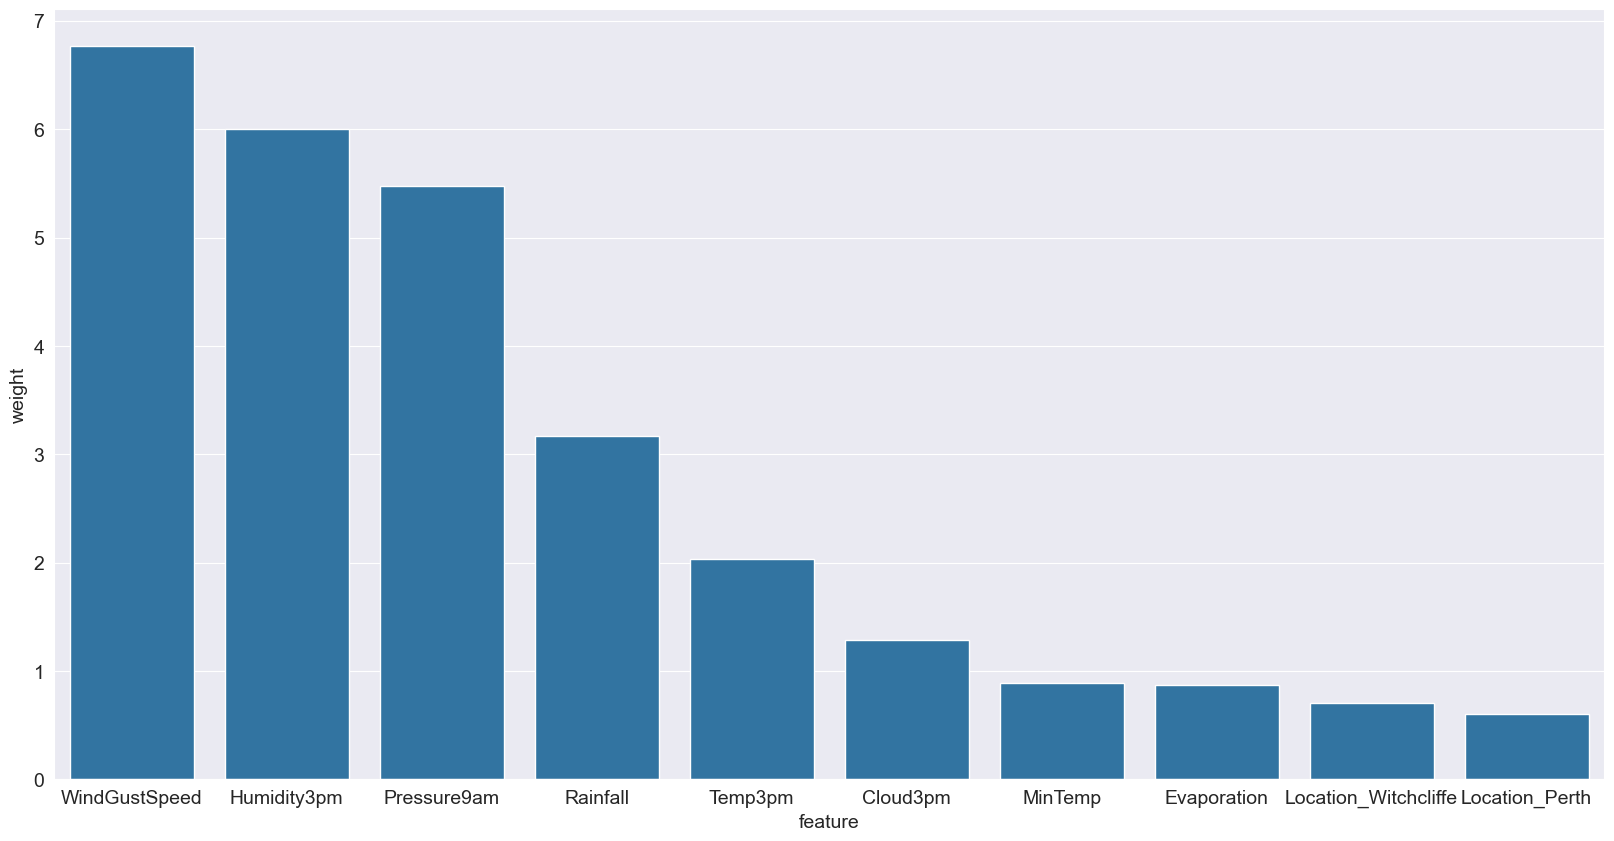

In [233]:
plt.figure(figsize=(20,10))
sns.barplot(data = weight_df.sort_values('weight', ascending = False).head(10), x =  'feature', y = 'weight')
    

#  Making Prediction and Evaluating the Model

In [235]:
x_train = train_inputs[numeric_cols + encoded_cols]
x_val = val_inputs[numeric_cols + encoded_cols]
x_test = test_inputs[numeric_cols + encoded_cols]

In [236]:
train_preds = model.predict(x_train)

In [237]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [238]:
train_target

,RainTomorrow
0,No
1,No
2,No
3,No
4,No
...,...
144548,No
144549,No
144550,No
144551,No


In [239]:
#    سيعطينا الاحتمالات بحيث ما احتمال ان تكون تنتمي للكلاس الاول والقيمه الثانيه للكلاس الثاني
train_probs = model.predict_proba(x_train)
train_probs

array([[0.94410393, 0.05589607],
       [0.9407789 , 0.0592211 ],
       [0.96099504, 0.03900496],
       ...,
       [0.98747367, 0.01252633],
       [0.98331685, 0.01668315],
       [0.87429673, 0.12570327]])

In [240]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [241]:
#  لقياس الدقه في مودل التصنيف
from sklearn.metrics import accuracy_score
accuracy_score(train_target, train_preds)

0.8519716700004082

In [242]:
from sklearn.metrics import confusion_matrix
confusion_matrix(train_target, train_preds, normalize = 'true')
#    FN يجب تقليل 

array([[0.94622654, 0.05377346],
       [0.477475  , 0.522525  ]])

In [243]:
def prdict_and_plot(inputs, targets, name = ' '):
    preds = model.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    cf = confusion_matrix(targets, preds, normalize = 'true')
    plt.figure()
    sns.heatmap(data = cf, annot= True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    return preds

Accuracy: 85.20%


array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

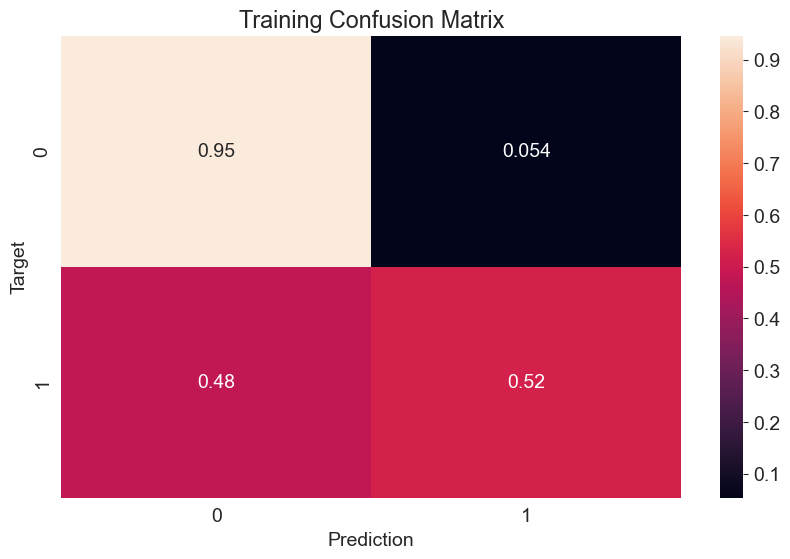

In [244]:
prdict_and_plot(x_train,train_target, 'Training')

Accuracy: 85.41%


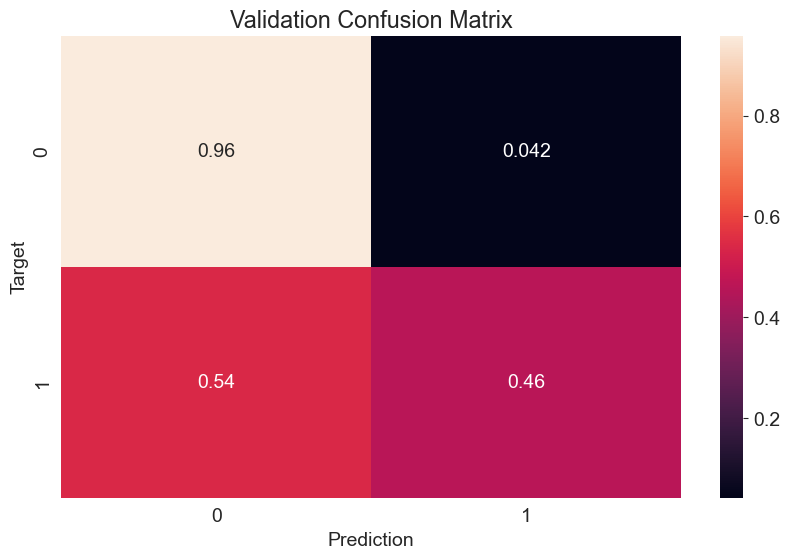

In [245]:
val_preds = prdict_and_plot(x_val, val_target, 'Validation')

Accuracy: 84.20%


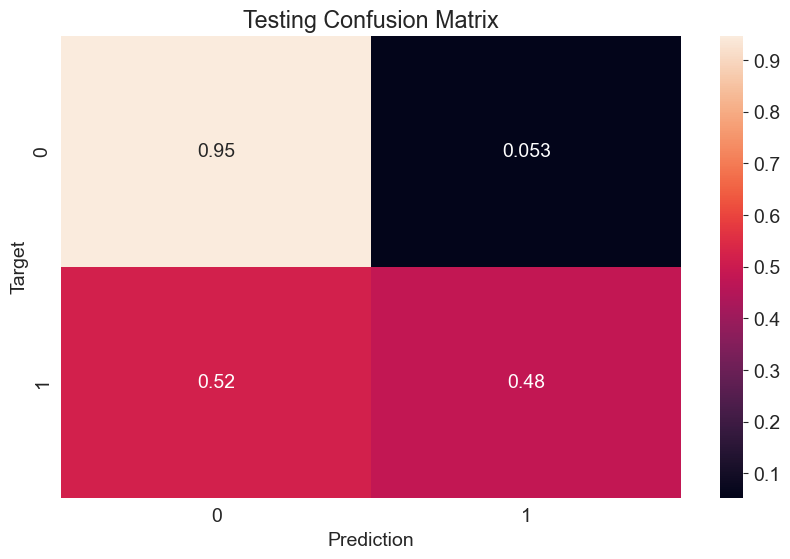

In [246]:
test_preds = prdict_and_plot(x_test, test_target, 'Testing')

انشاء نماذج ليست ذكيه للتاكد من عمل النموذج الذي لدينا

In [248]:
def random_guess(inputs):
    return np.random.choice(["No", "Yes"],len(inputs))

In [249]:
def all_no (inputs):
    return np.full(len(inputs), "No")

In [250]:
accuracy_score(test_target, random_guess(x_test))
#  منطقي

0.5024504084014002

In [251]:
accuracy_score(test_target, all_no(x_test))
#   بسبب عدم التوازن يحدث ذالك

0.7734344612991054

In [252]:
new_input = { 'Date' : '2021-06-19',
             'Location' : 'Katherin',
             'MinTemp' : 23.2,
             'MaxTemp' : 33.2,
             'Rainfall' : 10.2,
             'Evaporation' : 4.2,
             'Sunshine' : np.nan,
             'WindGustDir' : 'NNW',
             'WindGustSpeed' : 52.0,
             'WindDir9am' : 'NW',
             'WindDir3pm' : 'NNE',
             'WindSpeed9am' : 13.0,
             'WindSpeed3pm' : 20.0,
             'Humidity9am' : 89.0,
             'Humidity3pm' : 58.0,
             'Pressure9am' : 1004.8,
             'Pressure3pm' : 1001.5,
             'Cloud9am' : 8.0, 
             'Cloud3pm' : 5.0,
             'Temp9am' : 25.7,
             'Temp3pm' : 33.0,
             'RainToday' : 'Yes'
            }        

In [253]:
new_input_df = pd.DataFrame([new_input])
new_input_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,2021-06-19,Katherin,23.2,33.2,10.2,4.2,NaN,NNW,52.0,NW,...,20.0,89.0,58.0,1004.8,1001.5,8.0,5.0,25.7,33.0,Yes


In [254]:
new_input_df [numeric_cols] = imputer.transform(new_input_df[numeric_cols])
new_input_df [numeric_cols] = scaler.transform(new_input_df[numeric_cols])
new_input_df [encoded_cols] = encoder.transform(new_input_df[categorical_cols])

C:\Users\aa\AppData\Local\Temp\ipykernel_15796\320167253.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_input_df [encoded_cols] = encoder.transform(new_input_df[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\320167253.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_input_df [encoded_cols] = encoder.transform(new_input_df[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\320167253.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [255]:
x_new_input = new_input_df[numeric_cols + encoded_cols]
x_new_input

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_Unknown,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Yes
0,0.747642,0.718336,0.027493,0.028966,0.526244,0.356589,0.1,0.229885,0.89,0.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [256]:
prediction = model.predict(x_new_input)
prediction[0]

'Yes'

In [257]:
prob = model.predict_proba(x_new_input)
prob[0]

array([0.29626381, 0.70373619])

In [258]:
def predict_input(single_input):
    input_df = pd.DataFrame([new_input])
    input_df [numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df [numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df [encoded_cols] = encoder.transform(input_df[categorical_cols])
    x_input = input_df[numeric_cols + encoded_cols]
    prediction = model.predict(x_input)[0]
    prob = model.predict_proba(x_input)[0][list(model.classes_).index(prediction)]
    return prediction,prob   

In [259]:
new_input = { 'Date' : '2021-06-19',
             'Location' : 'Uluru',
             'MinTemp' : 23.2,
             'MaxTemp' : 33.2,
             'Rainfall' : 2.2,
             'Evaporation' : 4.2,
             'Sunshine' : np.nan,
             'WindGustDir' : 'NNW',
             'WindGustSpeed' : 52.0,
             'WindDir9am' : 'NW',
             'WindDir3pm' : 'NNE',
             'WindSpeed9am' : 13.0,
             'WindSpeed3pm' : 20.0,
             'Humidity9am' : 89.0,
             'Humidity3pm' : 58.0,
             'Pressure9am' : 1004.8,
             'Pressure3pm' : 1001.5,
             'Cloud9am' : 8.0, 
             'Cloud3pm' : 5.0,
             'Temp9am' : 25.7,
             'Temp3pm' : 33.0,
             'RainToday' : 'Yes'
            }        

In [260]:
predict_input(new_input)

C:\Users\aa\AppData\Local\Temp\ipykernel_15796\3164637711.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df [encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\3164637711.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df [encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\3164637711.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

('Yes', 0.7268724011732693)

# Saving and Loading Trained Models

In [262]:
import joblib

In [263]:
aussie_rain = {
    'model' : model,
    'imputer' : imputer,
    'scaler' : scaler,
    'encoder' : encoder,
    'input_cols' : input_cols,
    'target_cols' : target_col,
    'numeric_cols' : numeric_cols,
    'categorical_cols' : categorical_cols,
    'encoded_cols' : encoded_cols
}

In [264]:
joblib.dump(aussie_rain, 'aussie_rain.joblib')

['aussie_rain.joblib']

In [265]:
aussie_rain2 = joblib.load('aussie_rain.joblib')

In [266]:
test_pred = aussie_rain2['model'].predict(x_test)
accuracy_score(test_target, test_pred)

0.842045896538312

# Data Preprocessing

  

- Download the dataset

In [269]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package')

Skipping, found downloaded files in ".\weather-dataset-rattle-package" (use force=True to force download)


In [270]:
os.listdir('./weather-dataset-rattle-package')

['weatherAUS.csv']

In [271]:
raw_df = pd.read_csv('./weather-dataset-rattle-package/weatherAUS.csv')

In [272]:
raw_df.dropna(subset = ['RainToday', 'RainTomorrow'], inplace = True)

- Create training, validation and test sets

In [274]:
year = pd.to_datetime(raw_df.Date).dt.year
train_df, vald_df, test_df = raw_df[year < 2015], raw_df[year == 2015], raw_df[year > 2015] 

- Create inputs and targets

In [276]:
input_cols = list(raw_df.columns[1:22])
target = 'RainTomorrow'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target].copy()
test_inputs, test_targets = test_df[input_cols].copy(), test_df[target].copy()

- Identify numeric and categorical columns

In [278]:
numeric_cols = list(raw_df.select_dtypes(include = 'number').columns)
categorical_cols = list(raw_df.select_dtypes(include = 'object').columns)[1:-1]

In [279]:
len(numeric_cols)

16

- Impute missing numerical values

In [281]:
imputer = SimpleImputer(strategy = 'mean').fit(raw_df[numeric_cols])
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols]  = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols]  = imputer.transform(test_inputs[numeric_cols])

- Scale numeric features 

In [283]:
scaler = MinMaxScaler().fit(raw_df[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols]  = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols]  = scaler.transform(test_inputs[numeric_cols])

- One-hot encide categorical features

In [285]:
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore').fit(raw_df[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out())
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols]  = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols]  = encoder.transform(test_inputs[categorical_cols])

C:\Users\aa\AppData\Local\Temp\ipykernel_15796\4275345566.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\4275345566.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\4275345566.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

- Save processed data in disk (optional)

In [287]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
test_inputs.to_parquet('test_inputs.parquet') 
pd.DataFrame(train_target).to_parquet('train_target.parquet')
pd.DataFrame(val_target).to_parquet('val_target.parquet')
pd.DataFrame(test_target).to_parquet('test_target.parquet')  

- Load processed data from disk

In [289]:
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')
test_inputs = pd.read_parquet('test_inputs.parquet')

train_targets = pd.read_parquet('train_target.parquet')
val_targets = pd.read_parquet('val_target.parquet')
test_targets = pd.read_parquet('test_target.parquet')

- Model Training and Evaluation

In [546]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

In [548]:
# Select the columns to be for trainingh/prediction
x_train = train_inputs [ numeric_cols + encoded_cols]
x_val = val_inputs [ numeric_cols + encoded_cols]
x_test = test_inputs [ numeric_cols + encoded_cols]

In [550]:
# Create and train the model
model = LogisticRegression(solver = 'liblinear')
model.fit(x_train, train_targets)

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(solver='liblinear')

In [554]:
# Generate prediction and probabilities
train_preds = model.predict(x_train)
train_probs = model.predict_proba(x_train)
accuracy_score(train_targets, train_preds)

0.8519206433440829

In [556]:
# Helper function to predict compute accuracy & plot confustion matrix
def prdict_and_plot(inputs, targets, name = ' '):
    preds = model.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    cf = confusion_matrix(targets, preds, normalize = 'true')
    plt.figure()
    sns.heatmap(data = cf, annot= True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    return preds

Accuracy: 85.40%
Accuracy: 84.20%


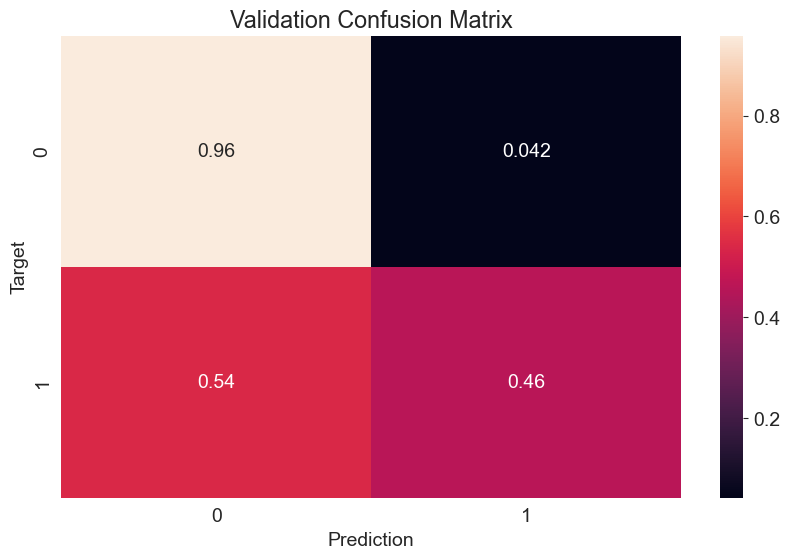

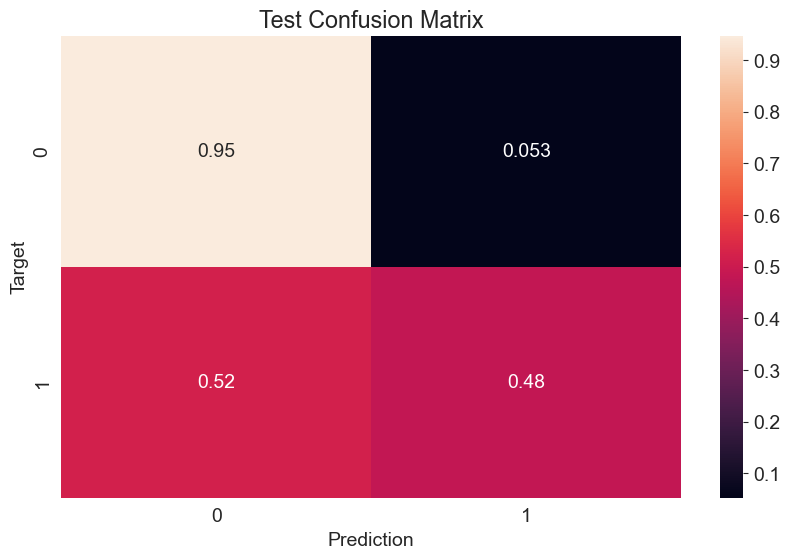

In [564]:
# Evaluate on validation and test set
val_preds = prdict_and_plot(x_val, val_targets, 'Validation')
test_preds = prdict_and_plot(x_test, test_targets, 'Test')

In [566]:
# Save the trained model & load it back
aussie_rain = {
    'model' : model,
    'imputer' : imputer,
    'scaler' : scaler,
    'encoder' : encoder,
    'input_cols' : input_cols,
    'target_cols' : target_col,
    'numeric_cols' : numeric_cols,
    'categorical_cols' : categorical_cols,
    'encoded_cols' : encoded_cols
}
joblib.dump(aussie_rain, 'aussie_rain.joblib')
aussie_rain2 = joblib.load('aussie_rain.joblib')

- Prediction on Single Inputs

In [569]:
def predict_input(single_input):
    input_df = pd.DataFrame([new_input])
    input_df [numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df [numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df [encoded_cols] = encoder.transform(input_df[categorical_cols])
    x_input = input_df[numeric_cols + encoded_cols]
    prediction = model.predict(x_input)[0]
    prob = model.predict_proba(x_input)[0][list(model.classes_).index(prediction)]
    return prediction,prob   

In [571]:
new_input = { 'Date' : '2021-06-19',
             'Location' : 'Uluru',
             'MinTemp' : 23.2,
             'MaxTemp' : 33.2,
             'Rainfall' : 2.2,
             'Evaporation' : 4.2,
             'Sunshine' : np.nan,
             'WindGustDir' : 'NNW',
             'WindGustSpeed' : 52.0,
             'WindDir9am' : 'NW',
             'WindDir3pm' : 'NNE',
             'WindSpeed9am' : 13.0,
             'WindSpeed3pm' : 20.0,
             'Humidity9am' : 89.0,
             'Humidity3pm' : 58.0,
             'Pressure9am' : 1004.8,
             'Pressure3pm' : 1001.5,
             'Cloud9am' : 8.0, 
             'Cloud3pm' : 5.0,
             'Temp9am' : 25.7,
             'Temp3pm' : 33.0,
             'RainToday' : 'Yes'
            }     
predict_input(new_input)

C:\Users\aa\AppData\Local\Temp\ipykernel_15796\3164637711.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df [encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\3164637711.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df [encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\aa\AppData\Local\Temp\ipykernel_15796\3164637711.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

('Yes', 0.7268772369405446)